- Filename: ViT-GSOM_training_MNIST.ipynb
- Author: Tomas Hanzlik <hanzlto3@fit.cvut.cz>
- Created: 2026-04-22
- Description: Training and visualizations of the ViT-GSOM model on the MNIST dataset

# ViT-GSOM training on MNIST dataset

Training the ViT-GSOM model to compare achieved performance with the ViT-SOM performance

In [21]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import ConcatDataset

import numpy as np
import matplotlib.pyplot as plt

from ViTGSOM import AutoEncoder, ViTLossReconstruction, SomLoss
from help_functions import get_grid_coords, decay_exponential, calculate_QE_TE_Purity, plot_umap_som_weights, get_node_hits, plot_som_weights, plot_som_mnist, plot_som_pie_grid, generate_extended_u_matrix, visualize_u_matrix_extended 

Download and concatenate the dataset

In [22]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])

train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
dataset = ConcatDataset([train_set, test_set])

In [23]:
config = {
    'img_size': 28,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'epochs_pretrain': 20,
    'epochs_som': 500,
    'fine_tuning_epochs': 100,
    'lr': 0.0005,
    'grow_after_epochs': 10,
    'som_rows': 10,
    'som_cols': 10,
    'stop_growth_purity': 0.90
}

Initialize the ViT-SOM

Details:
- Image size of 28
- Pixel size of 4
- 1 image channel
- Embedding dimension of 16
- Encoder depth of 4
- Decoder depth of 2
- 2 self-attention head
- MLP hidden dimension of size 64
- 20 Phase 1 epochs
- 500 Phase 2 epochs
- 100 Phase 3 epochs
- Learning rate of 0.0005
- Grow each grid after 10 epochs
- Initial 10 SOM rows
- Initial 10 SOM columns
- Stop Phase 2 at 0.90 Purity


In [24]:
autoencoder = AutoEncoder(img_size=config['img_size'], 
                          patch_size=config['patch_size'], 
                          num_of_channels=config['num_of_channels'], 
                          embed_dim=config['embed_dim'], 
                          enc_depth=config['enc_depth'],                                      
                          dec_depth=config['dec_depth'], 
                          num_heads=config['num_heads'], 
                          mlp_dim=config['mlp_dim'],
                          som_rows=config['som_rows'],
                          som_cols=config['som_cols'])    

Initialize loss functions, loader and allow gpu computing

In [25]:
criterionViT = ViTLossReconstruction()
criterionSOM = SomLoss()

loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)
autoencoder.train()

AutoEncoder(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbedding(
      (proj): Conv2d(1, 16, kernel_size=(4, 4), stride=(4, 4))
    )
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=16, out_features=64, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_features=64, out_features=16, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): ViTDecoder(
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLine

## Phase 1: Pretrain ViT

In [26]:
# define parameters for which the gradients will be computed
autoencoder.som_weights.requires_grad = False
for param in autoencoder.encoder.parameters():
    param.requires_grad = True
for param in autoencoder.decoder.parameters():
    param.requires_grad = True
    
# define optimizer and scheduler with active parameters
paramsViT = list(autoencoder.encoder.parameters()) + list(autoencoder.decoder.parameters())
optimizerViT = optim.AdamW(paramsViT, lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerViT, T_max=config['epochs_pretrain'])

history = {'MSE': []}

for epoch in range(config['epochs_pretrain']):
    running_mse = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        # calculate loss
        l_nn = criterionViT(images, reconstructed)
        
        # update the active weights of the network
        optimizerViT.zero_grad()
        l_nn.backward()
        optimizerViT.step()
        running_mse += l_nn.item()
        
    scheduler.step()
    history['MSE'].append(running_mse/len(loader))
        
    print(f"Epoch {epoch+1}/{config['epochs_pretrain']}: MSE Loss {running_mse/len(loader):.8f}")

Epoch 1/20: MSE Loss 0.01134537
Epoch 2/20: MSE Loss 0.00155062
Epoch 3/20: MSE Loss 0.00084949
Epoch 4/20: MSE Loss 0.00061975
Epoch 5/20: MSE Loss 0.00053694
Epoch 6/20: MSE Loss 0.00048528
Epoch 7/20: MSE Loss 0.00043371
Epoch 8/20: MSE Loss 0.00041130
Epoch 9/20: MSE Loss 0.00039678
Epoch 10/20: MSE Loss 0.00038344
Epoch 11/20: MSE Loss 0.00037082
Epoch 12/20: MSE Loss 0.00036103
Epoch 13/20: MSE Loss 0.00035491
Epoch 14/20: MSE Loss 0.00035146
Epoch 15/20: MSE Loss 0.00034953
Epoch 16/20: MSE Loss 0.00034830
Epoch 17/20: MSE Loss 0.00034749
Epoch 18/20: MSE Loss 0.00034699
Epoch 19/20: MSE Loss 0.00034664
Epoch 20/20: MSE Loss 0.00034647


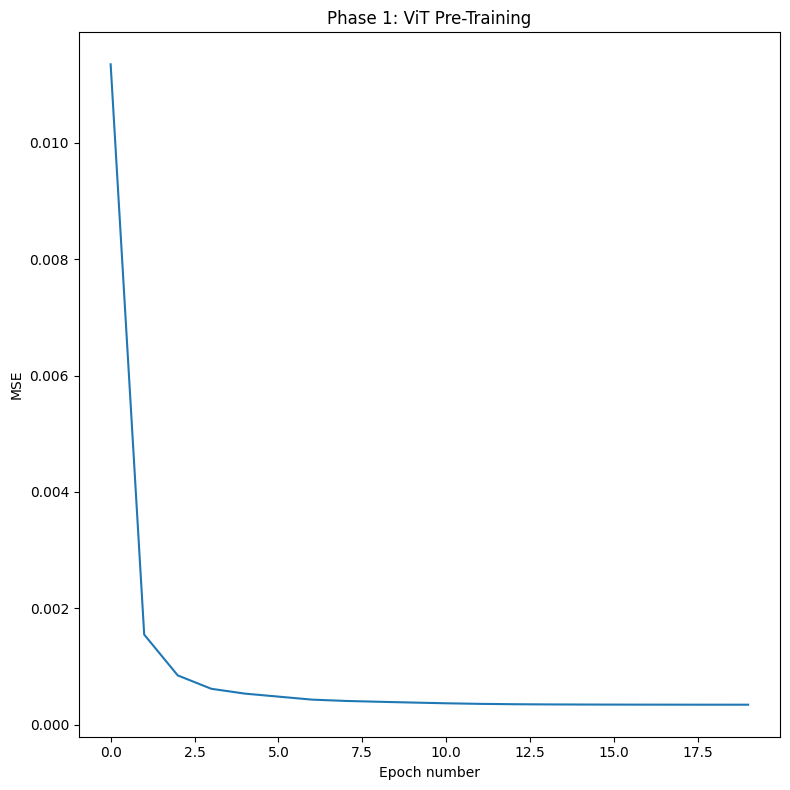

In [27]:
plt.figure(figsize=(8, 8))
plt.plot(np.arange(config['epochs_pretrain']), history['MSE'])
plt.ylabel('MSE')
plt.xlabel('Epoch number')
plt.title('Phase 1: ViT Pre-Training')
plt.tight_layout()
plt.savefig("phase1.png", dpi=300, bbox_inches='tight')
plt.show()

## Phase 2: GSOM training

In [28]:
# define parameters for which the gradients will be computed
autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

# define optimizer and scheduler with active parameters
paramsSOM = autoencoder.som_weights
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'])

# starting and ending value of sigma, beta is calculated to reach sigma_end at last epoch
sigma_start = autoencoder.get_sigma()
sigma_end = 0.3
beta = (sigma_end / sigma_start) ** (1 / config['grow_after_epochs'])
epochs_since_reset = 0

# get grid coordinates of each cell on the SOM grid
grid_coords = get_grid_coords(config['som_rows'], config['som_cols'], device)
current_sigma = sigma_start

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}

# snapshots for visualizations
snapshot_som_weights = {}
snapshot_som_weights[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

# set to calculate unique labels
unique_labels = set()

print("Start GSOM training")
for epoch in range(config['epochs_som']):
    
    running_som = 0.0
    # calculate current sigma value
    sigma_t = decay_exponential(sigma_start, beta, epochs_since_reset)

    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()

        # calculate loss
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)

        # update the active weights of the network
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['epochs_som']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")
        
    # condition to grow the map
    if epoch > 0 and (epoch + 1) % config['grow_after_epochs'] == 0:     
        # save snapshot for visualization
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights[epoch+1] = (weights_np, labels_np)

        if metrics["Purity"] > config['stop_growth_purity']:
            print(f"Purity is high enough: {metrics["Purity"]}, entering Phase 3 - Fine-tuning")
            break
        
        # grow the map
        epochs_since_reset += 1
        autoencoder.start_growth(loader, device)
        print(f"Current grid size: ({autoencoder.current_row_num}, {autoencoder.current_col_num})")

        # reset optimizer, scheduler, grid coordinates and sigma
        paramsSOM = autoencoder.get_som_weights()
        optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])

        for param_group in optimizerSOM.param_groups: param_group['initial_lr'] = config['lr']

        scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'], last_epoch=epoch)
        grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)

        sigma_start = autoencoder.get_sigma()
        sigma_start = max(sigma_start, 2.0)
        beta = (sigma_end / sigma_start) ** (1 / max(1, config['grow_after_epochs']))
        epochs_since_reset = 0

    else:
        epochs_since_reset += 1   

Start GSOM training
Epoch 1/500 | Sigma: 5.000 | SOM: 36.81720486) | QE: 0.2194 | TE: 0.9112 | Purity: 0.11310
Epoch 2/500 | Sigma: 3.774 | SOM: 7.63597699) | QE: 0.0641 | TE: 0.9811 | Purity: 0.11590
Epoch 3/500 | Sigma: 2.848 | SOM: 2.04027812) | QE: 0.0524 | TE: 0.4135 | Purity: 0.34746
Epoch 4/500 | Sigma: 2.150 | SOM: 1.04190414) | QE: 0.0450 | TE: 0.0634 | Purity: 0.60894
Epoch 5/500 | Sigma: 1.623 | SOM: 0.54633989) | QE: 0.0402 | TE: 0.0162 | Purity: 0.67569
Epoch 6/500 | Sigma: 1.225 | SOM: 0.31591110) | QE: 0.0376 | TE: 0.0238 | Purity: 0.72930
Epoch 7/500 | Sigma: 0.924 | SOM: 0.18465091) | QE: 0.0354 | TE: 0.0366 | Purity: 0.75221
Epoch 8/500 | Sigma: 0.698 | SOM: 0.10600216) | QE: 0.0335 | TE: 0.0599 | Purity: 0.78129
Epoch 9/500 | Sigma: 0.527 | SOM: 0.06052564) | QE: 0.0319 | TE: 0.1177 | Purity: 0.82021
Epoch 10/500 | Sigma: 0.397 | SOM: 0.03791030) | QE: 0.0306 | TE: 0.2047 | Purity: 0.84324
Current grid size: (10, 11)
Epoch 11/500 | Sigma: 5.000 | SOM: 3.07691197) | Q

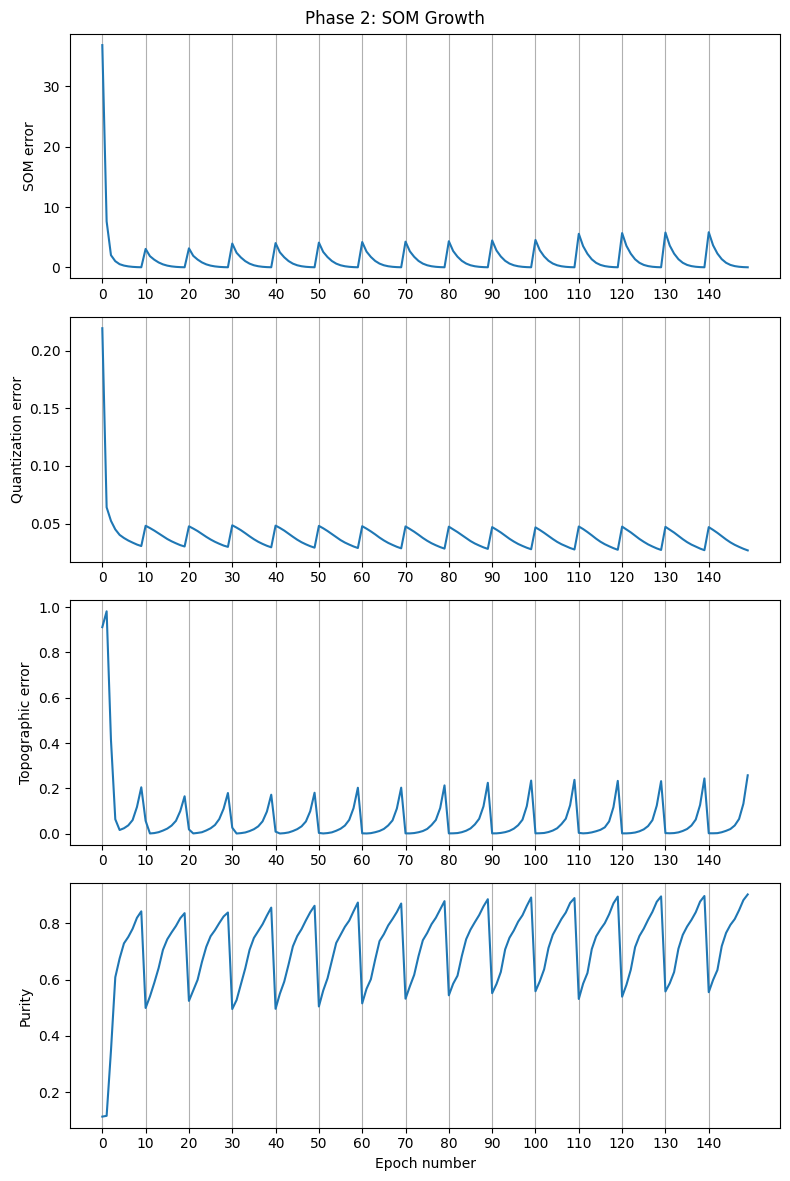

In [29]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed, 10)

plt.figure(figsize=(8, 12))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.suptitle("Phase 2: SOM Growth")
plt.savefig("phase2.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

Plot the change of the UMAP throughout the Phase 2

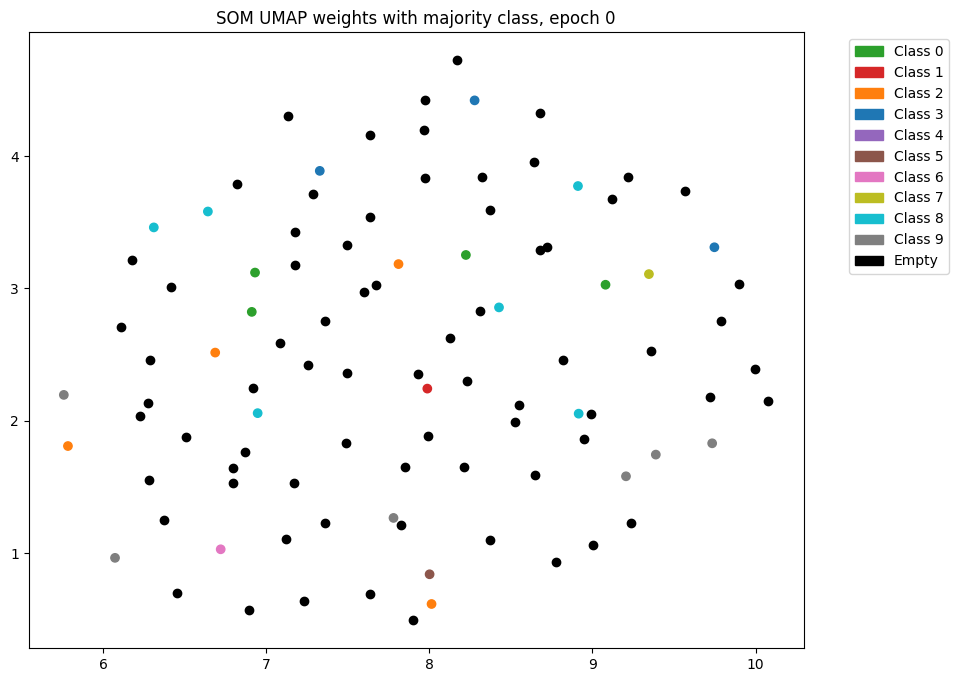

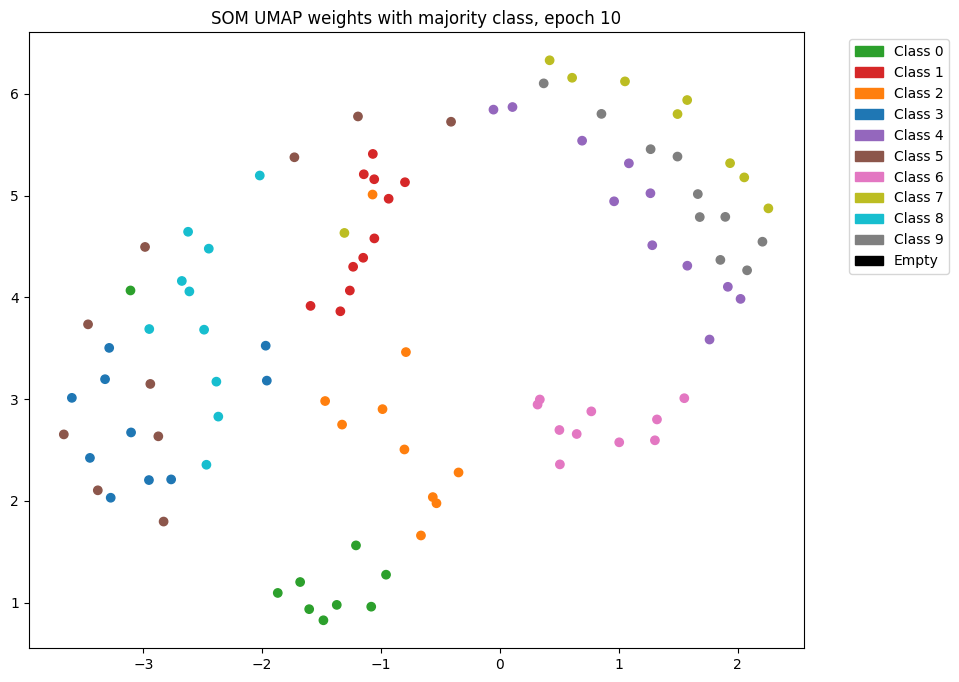

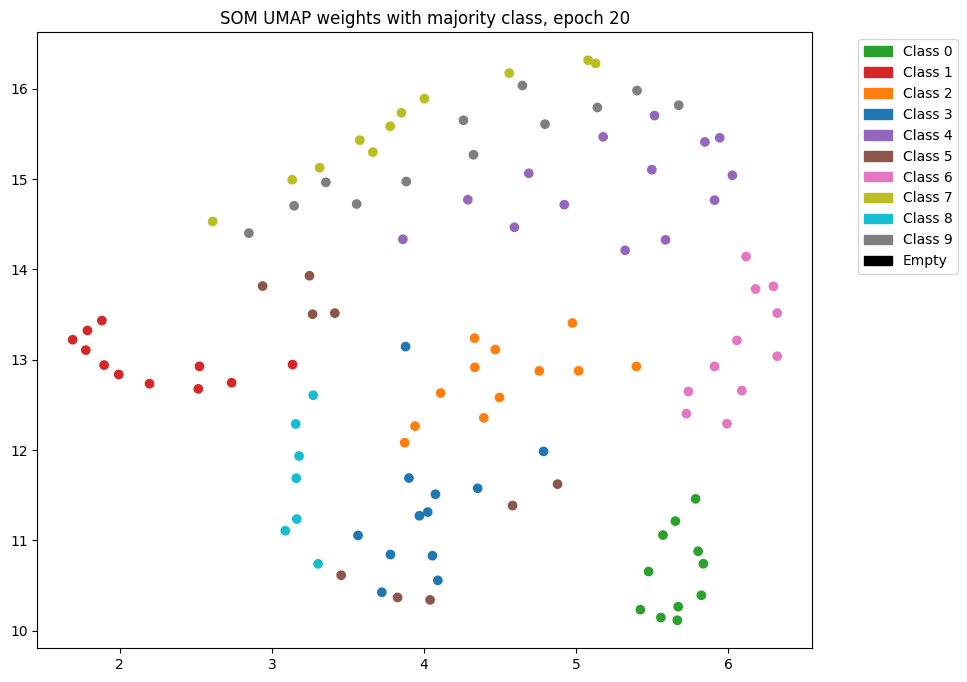

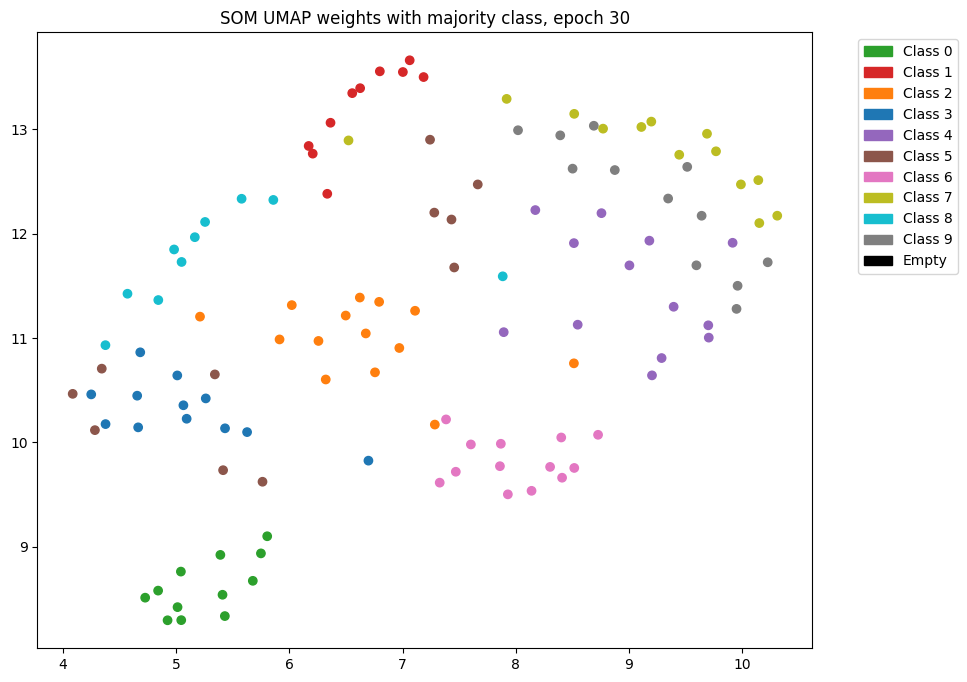

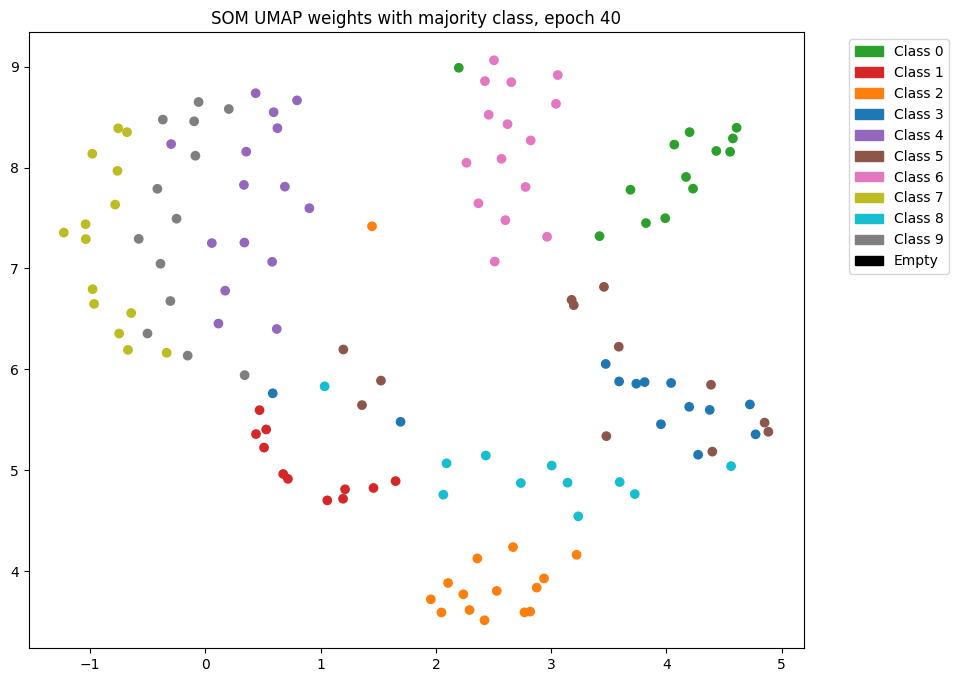

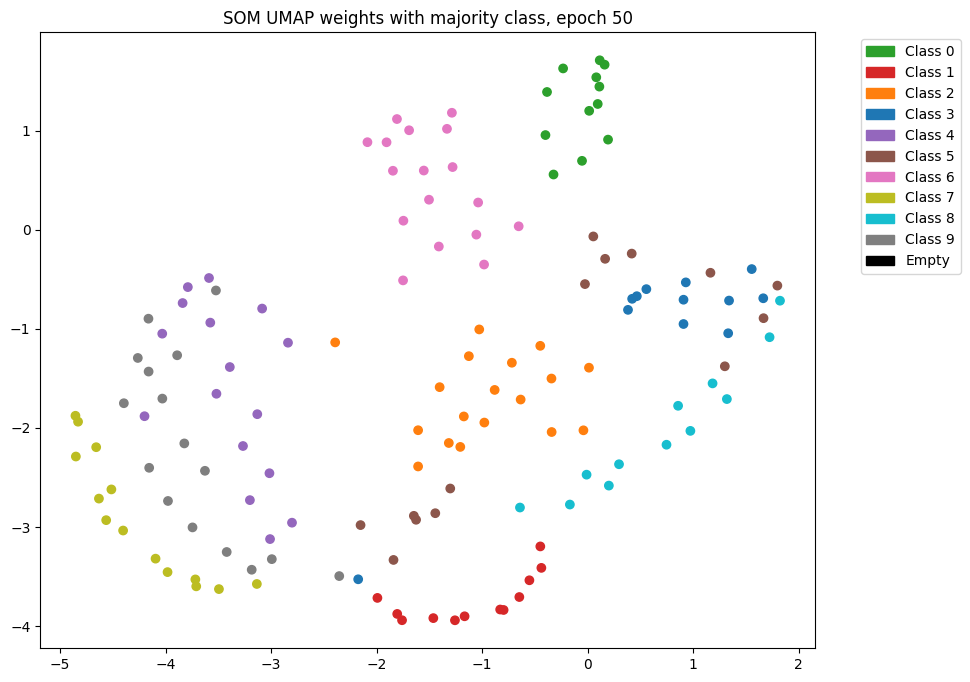

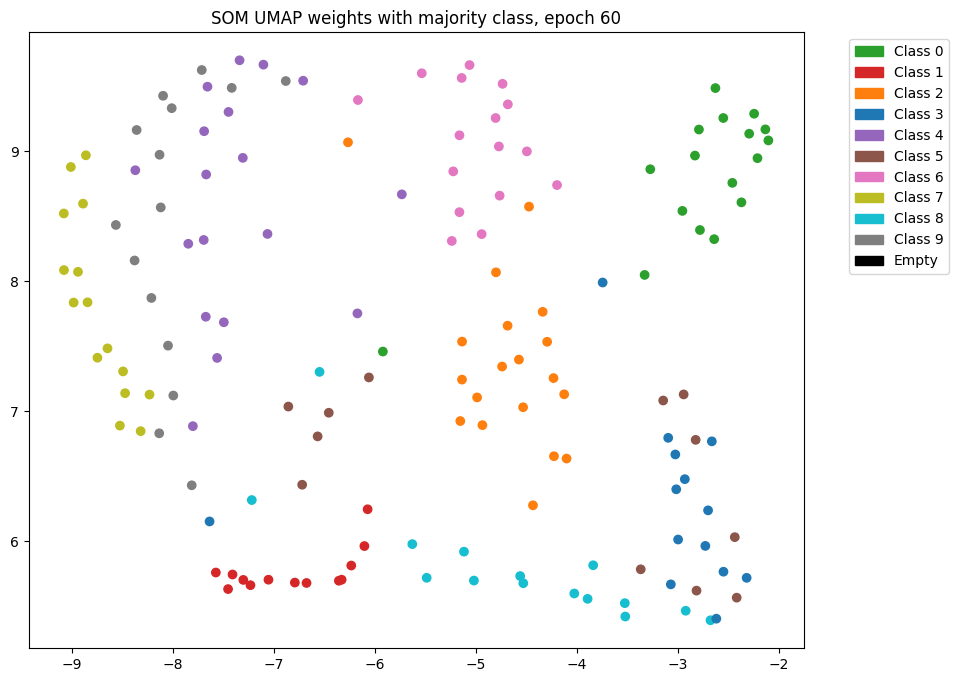

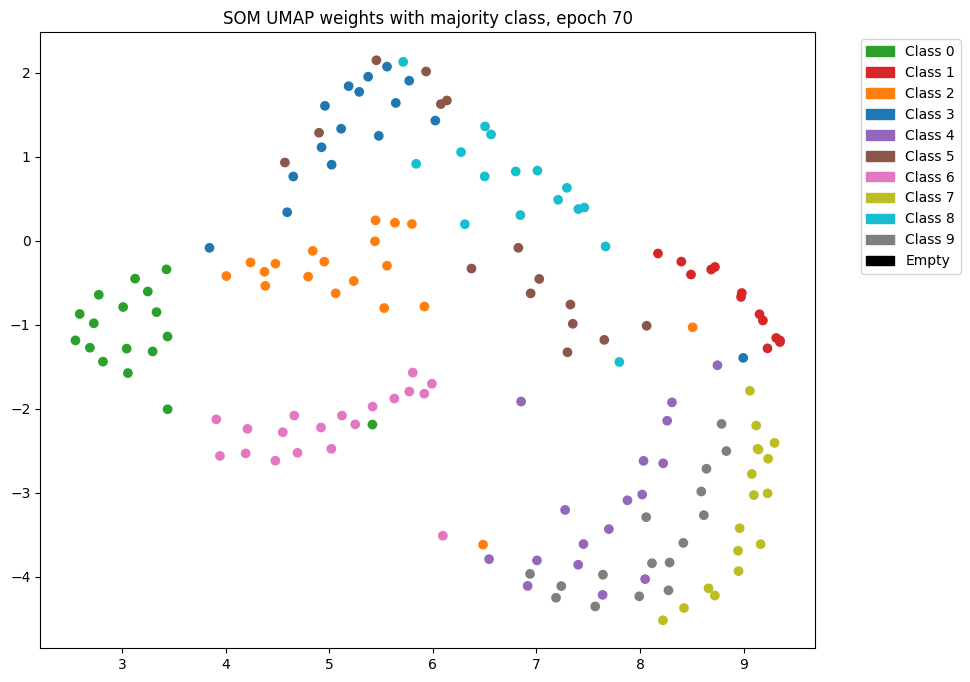

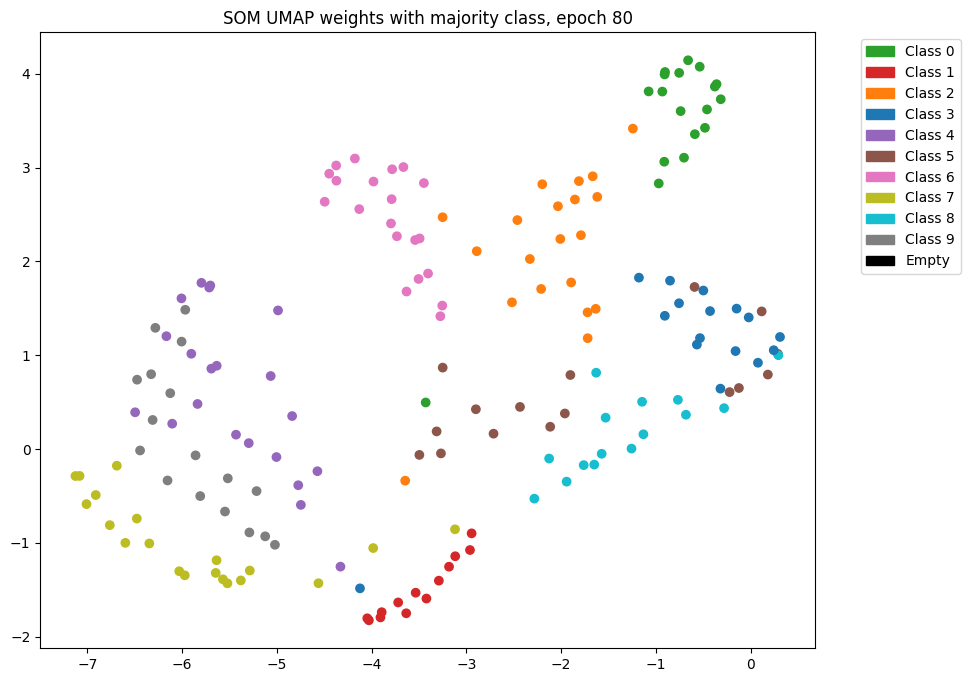

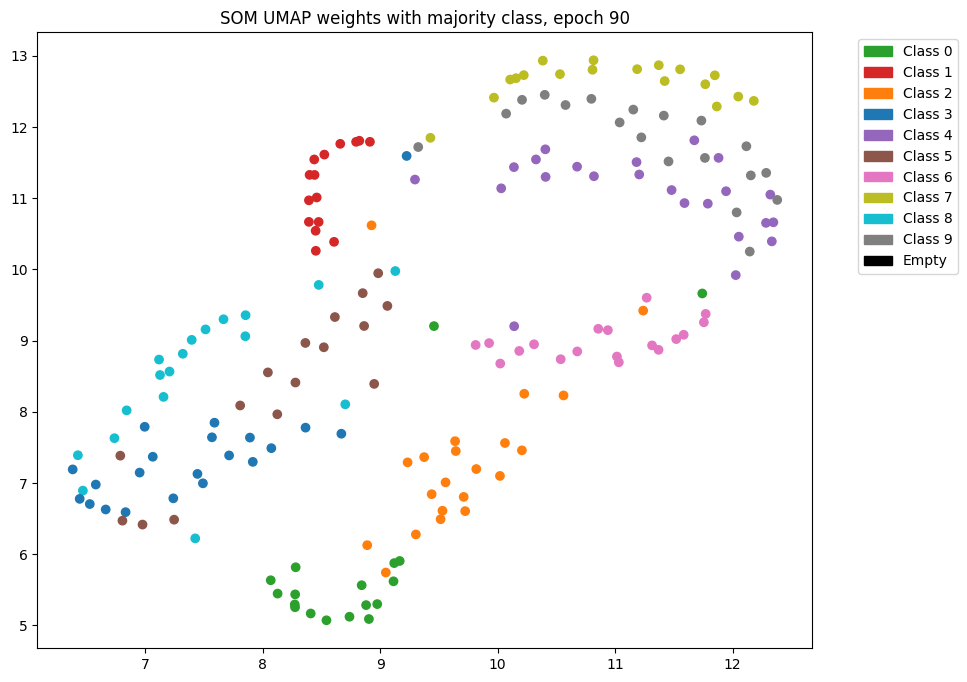

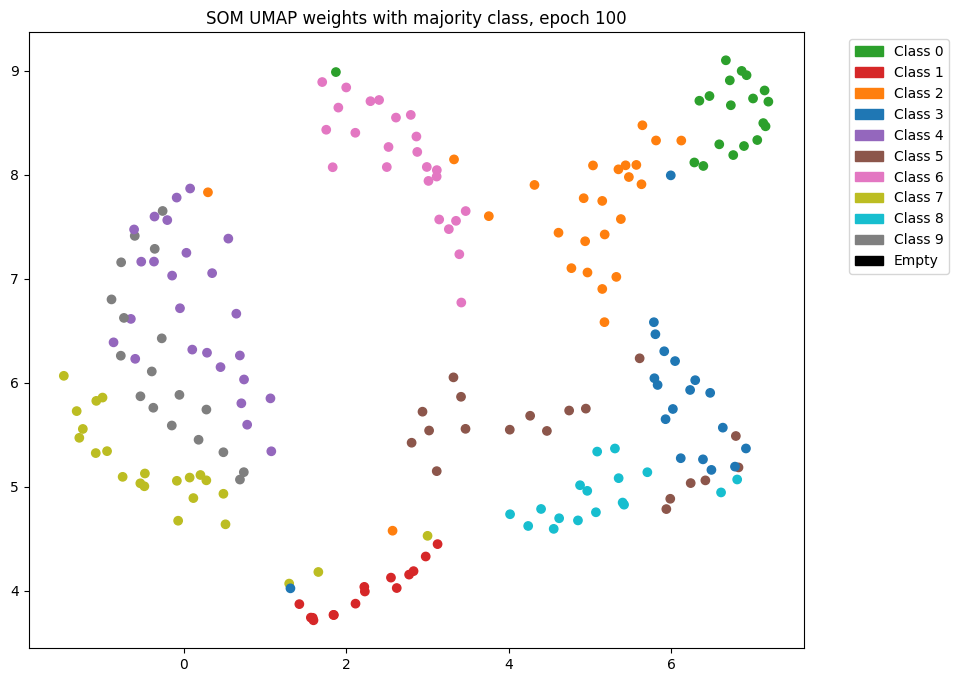

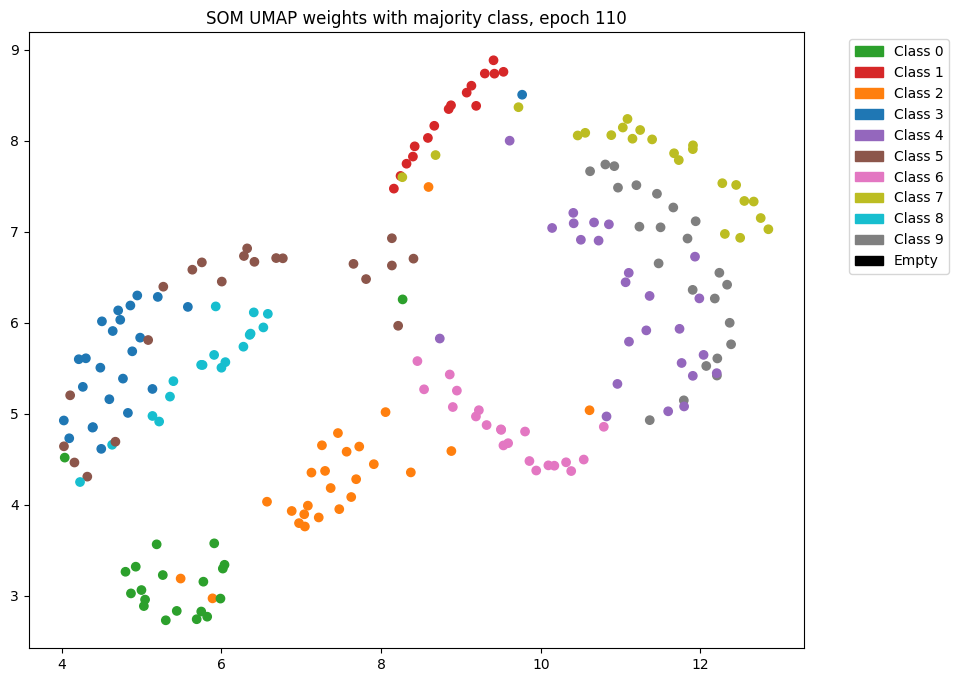

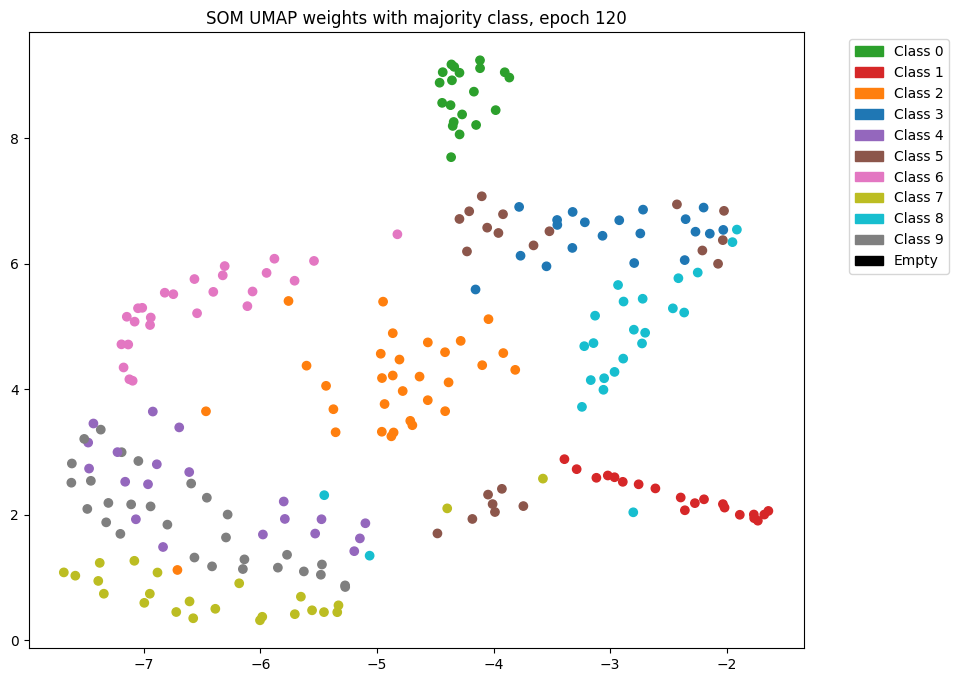

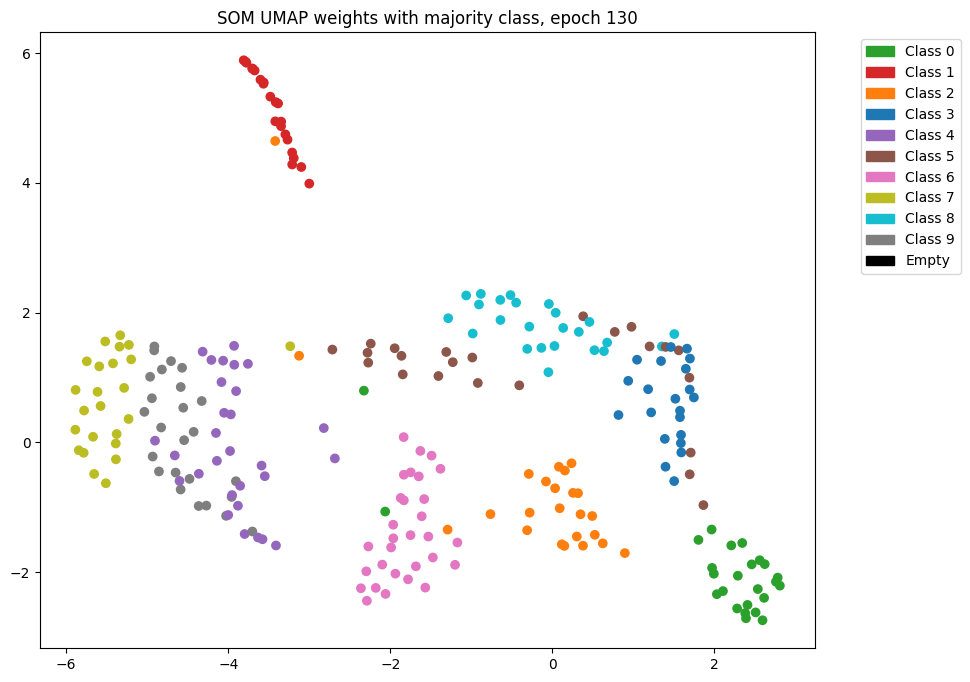

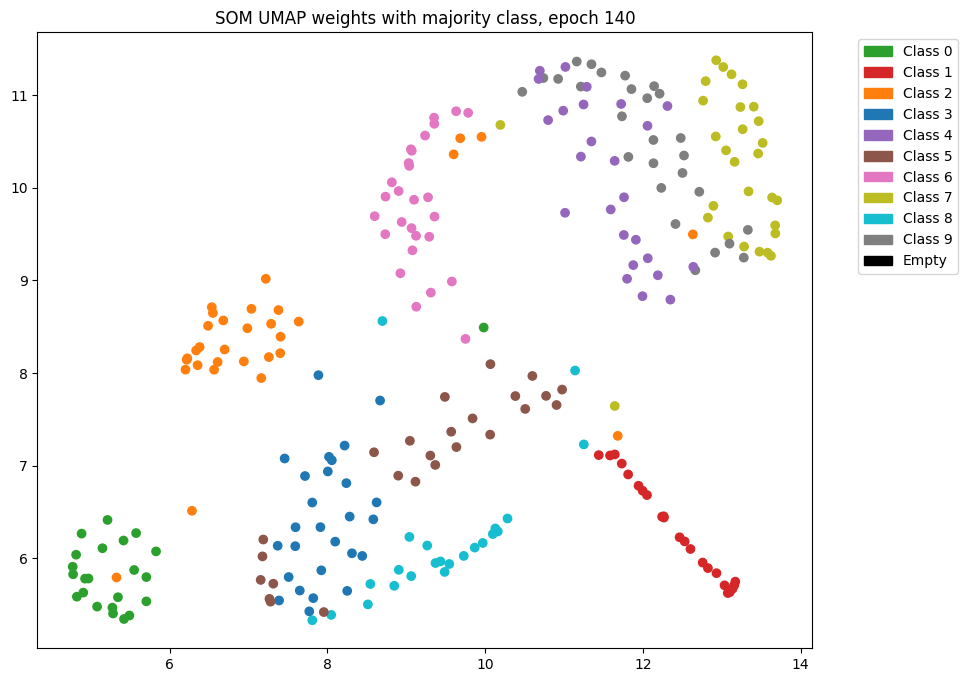

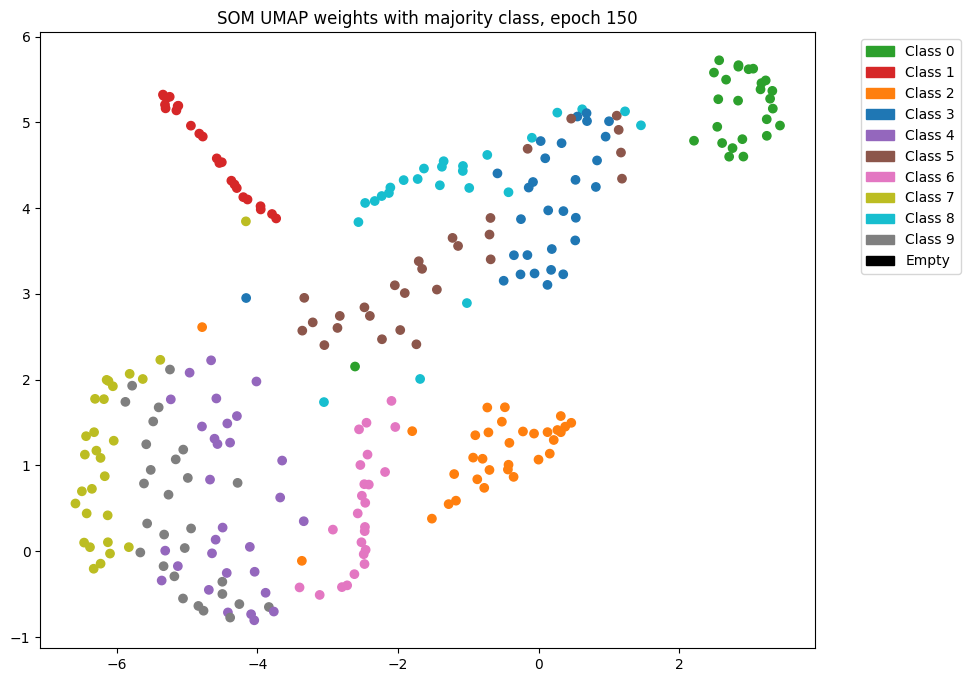

In [30]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

Plot Extended U-Matrix after Phase 2

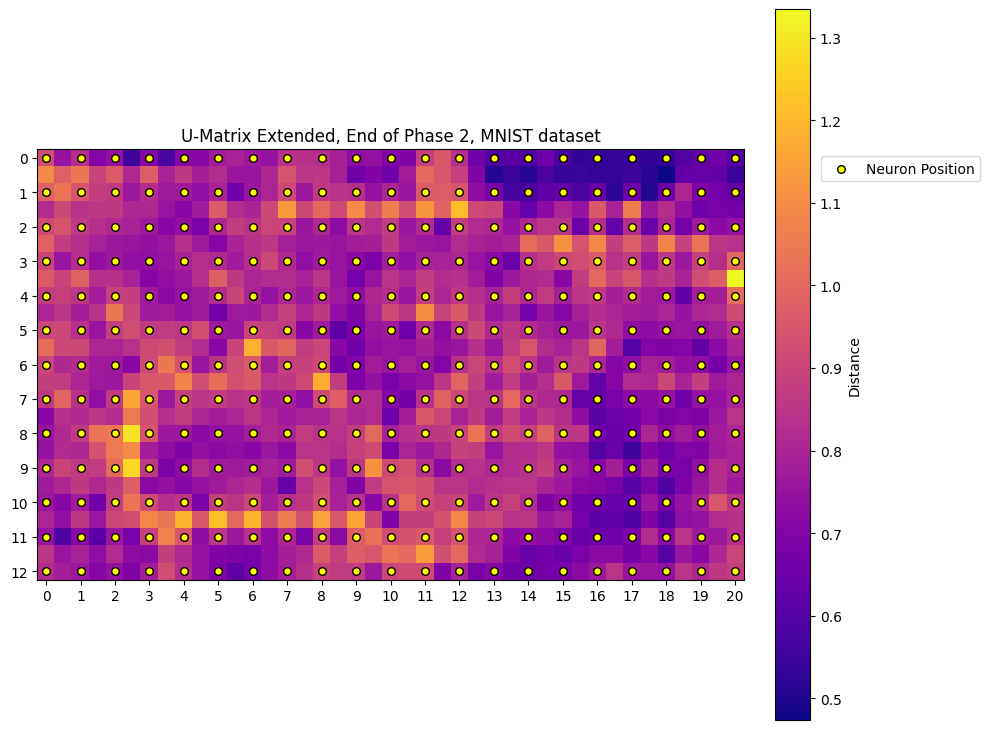

In [31]:
rows, cols = autoencoder.get_som_shape()
matrix = generate_extended_u_matrix(autoencoder.get_som_weights().detach().cpu().numpy(), rows, cols)
visualize_u_matrix_extended(matrix, "End of Phase 2, MNIST dataset")

Plot the majority class with the numbers representing the class

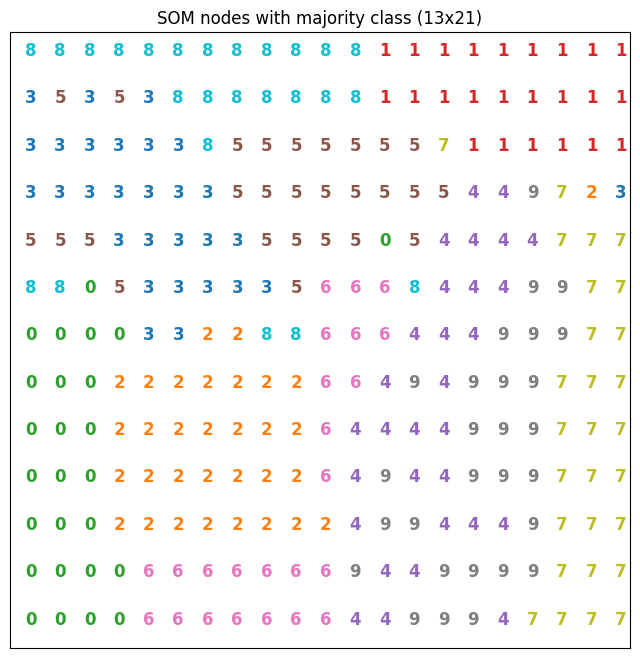

In [32]:
plot_som_mnist(snapshot_som_weights, rows, cols)

## Phase 3: ViT-GSOM Fine-Tuning

In [33]:
final_rows, final_cols = autoencoder.get_som_shape()

# define parameters for which the gradients will be computed
autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

# define optimizer and scheduler with active parameters
paramsSOM = autoencoder.get_som_weights()
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['fine_tuning_epochs'], last_epoch=-1)

# starting and ending value of sigma, beta is calculated to reach sigma_end at last epoch
sigma_start = 2
sigma_end = 0.01
beta = (sigma_end / sigma_start) ** (1 / config['fine_tuning_epochs'])

# get grid coordinates of each cell on the SOM grid
grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)
current_sigma = sigma_start

# snapshots for visualizations
checkpoints = [i for i in range(0, config['fine_tuning_epochs'] + 1, 10)]
snapshot_som_weights_finetuning = {}
snapshot_som_weights_finetuning[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}

print("Start training")
for epoch in range(config['fine_tuning_epochs']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    last_sigma = sigma_t
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent = autoencoder(images)
        som_weights = autoencoder.get_som_weights()

        # calculate loss
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)

        # update the active weights of the network
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['fine_tuning_epochs']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f} | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")

    if epoch+1 in checkpoints:        
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights_finetuning[epoch+1] = (weights_np, labels_np)

Start training
Epoch 1/100 | Sigma: 2.000 | SOM: 0.82043060 | QE: 0.0363 | TE: 0.0115 | Purity: 0.76787
Epoch 2/100 | Sigma: 1.897 | SOM: 0.72074997 | QE: 0.0359 | TE: 0.0120 | Purity: 0.76990
Epoch 3/100 | Sigma: 1.799 | SOM: 0.65150118 | QE: 0.0354 | TE: 0.0138 | Purity: 0.77603
Epoch 4/100 | Sigma: 1.706 | SOM: 0.58836460 | QE: 0.0350 | TE: 0.0147 | Purity: 0.78077
Epoch 5/100 | Sigma: 1.618 | SOM: 0.53129371 | QE: 0.0346 | TE: 0.0158 | Purity: 0.78803
Epoch 6/100 | Sigma: 1.535 | SOM: 0.47979365 | QE: 0.0341 | TE: 0.0183 | Purity: 0.79061
Epoch 7/100 | Sigma: 1.455 | SOM: 0.43303457 | QE: 0.0337 | TE: 0.0199 | Purity: 0.79107
Epoch 8/100 | Sigma: 1.380 | SOM: 0.39100235 | QE: 0.0333 | TE: 0.0214 | Purity: 0.79506
Epoch 9/100 | Sigma: 1.309 | SOM: 0.35217693 | QE: 0.0329 | TE: 0.0235 | Purity: 0.79667
Epoch 10/100 | Sigma: 1.241 | SOM: 0.31713021 | QE: 0.0326 | TE: 0.0268 | Purity: 0.80353
Epoch 11/100 | Sigma: 1.177 | SOM: 0.28556882 | QE: 0.0322 | TE: 0.0298 | Purity: 0.80480
Epoc

Plot the change of the extended U-Matrix throughout the training process

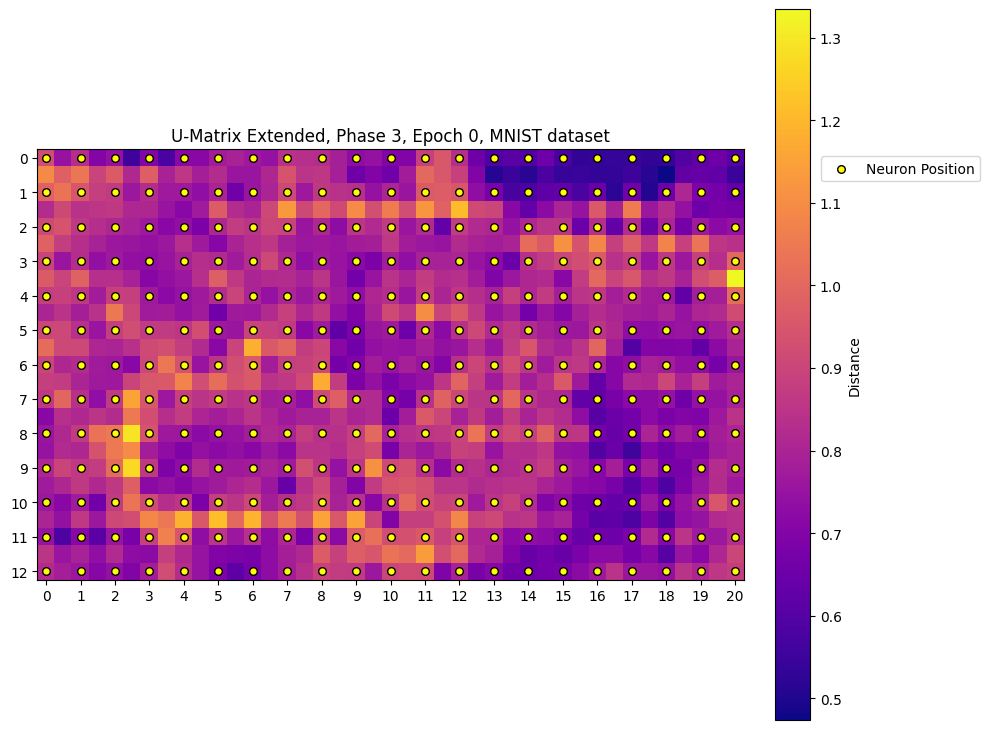

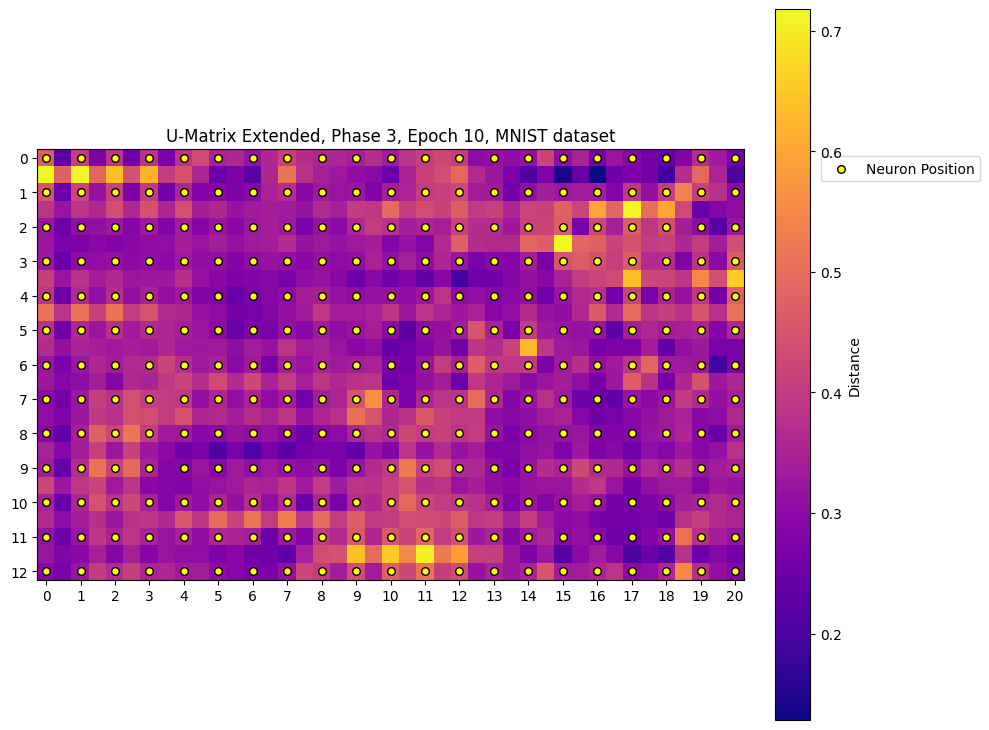

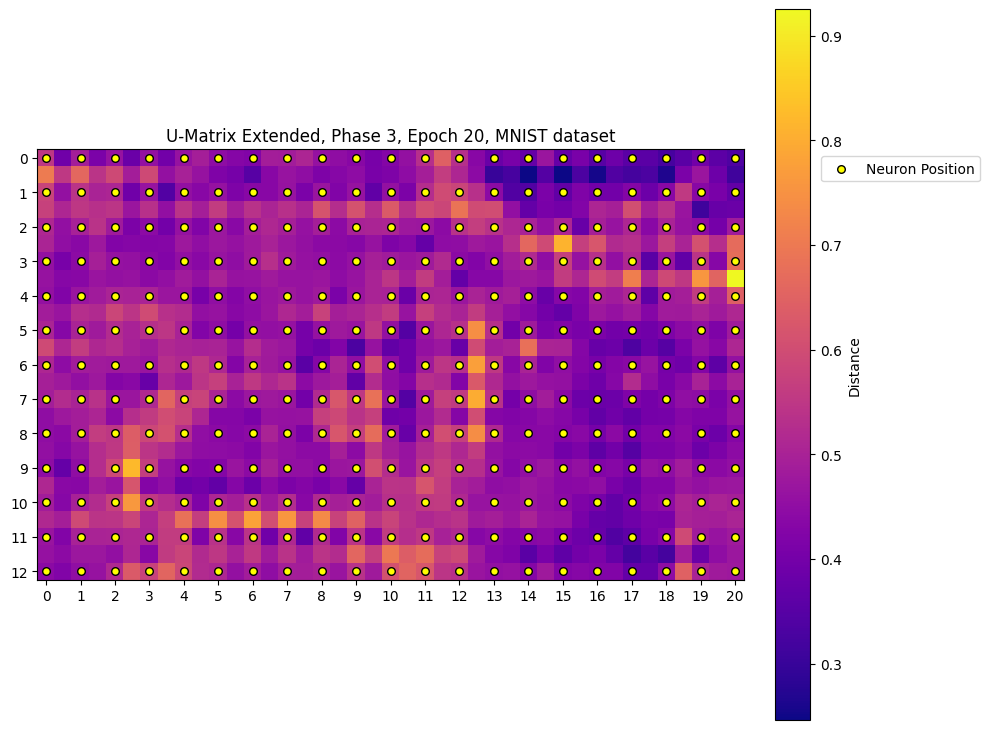

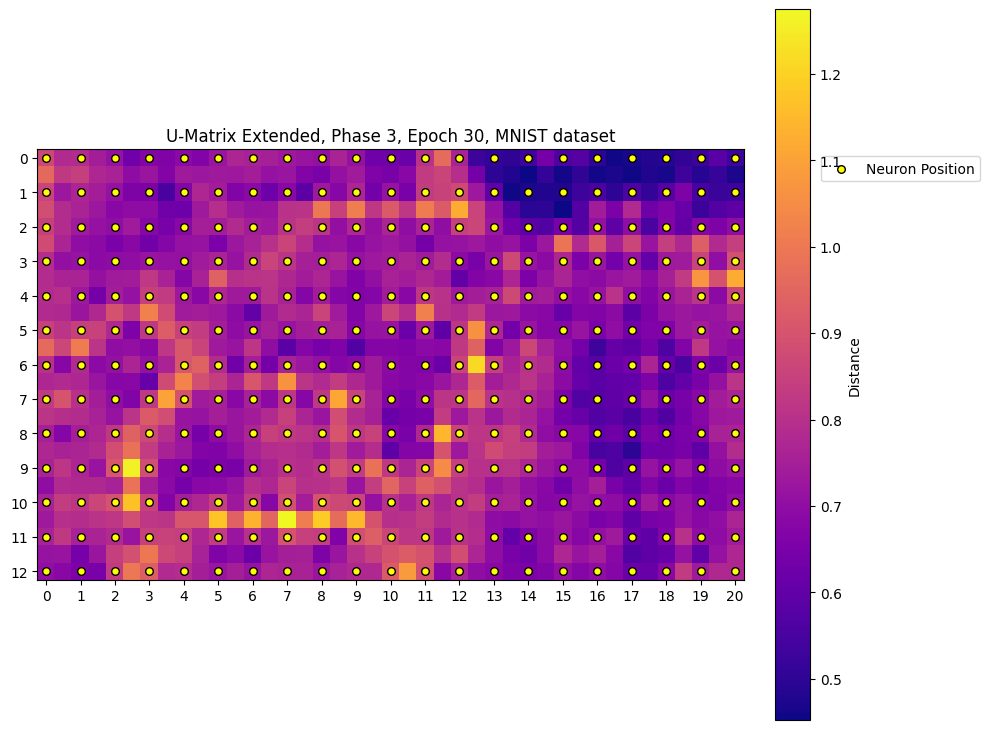

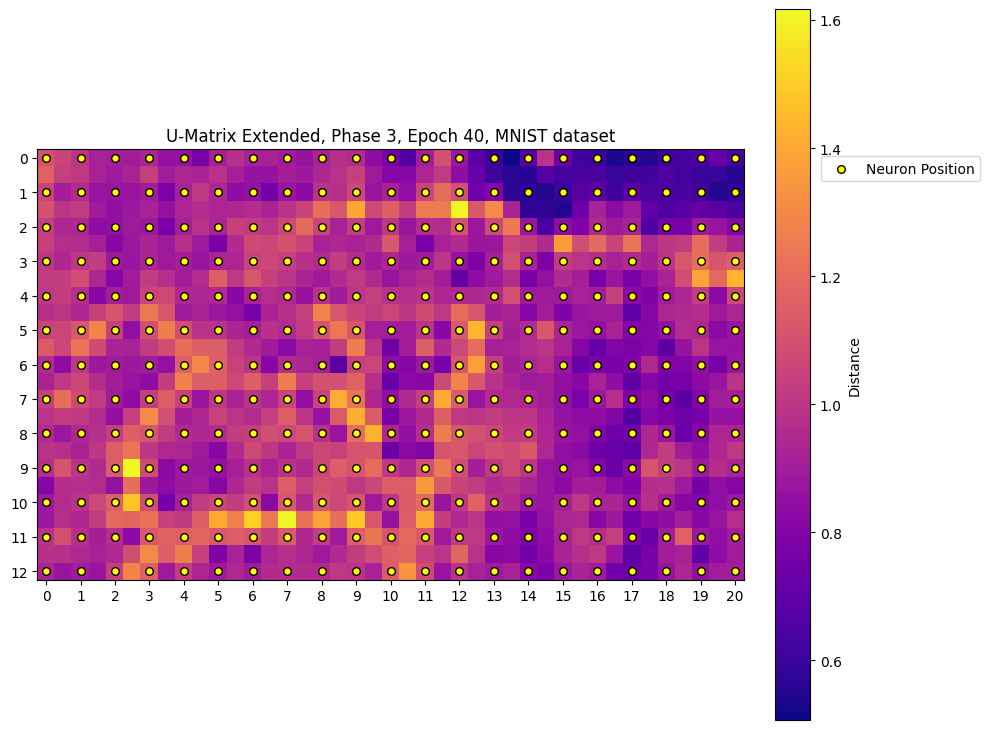

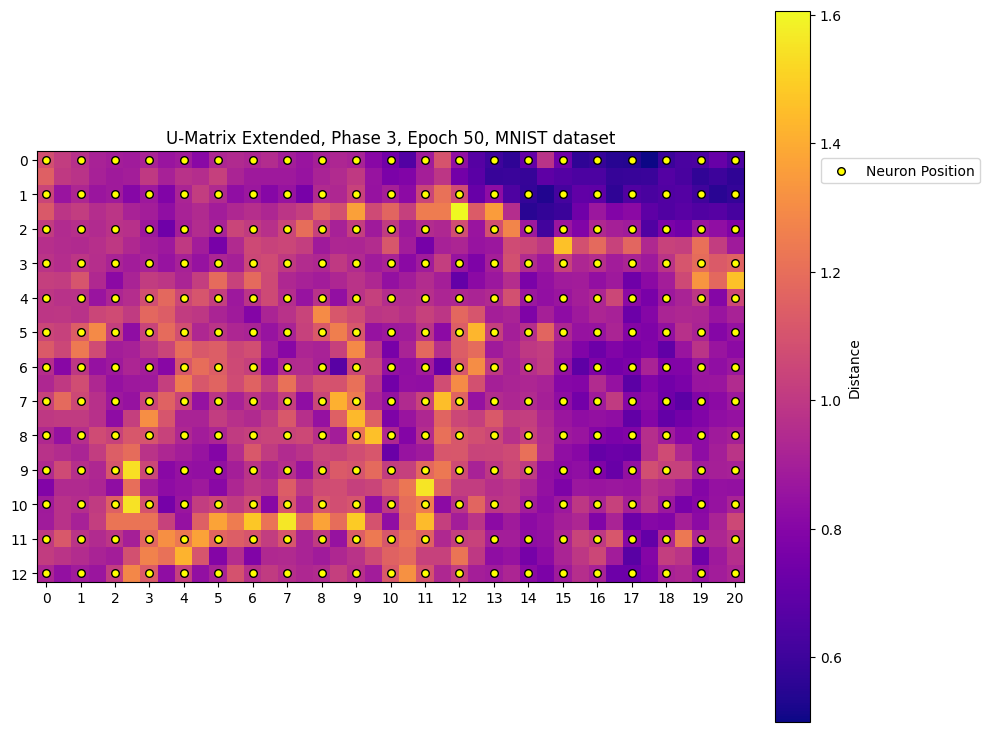

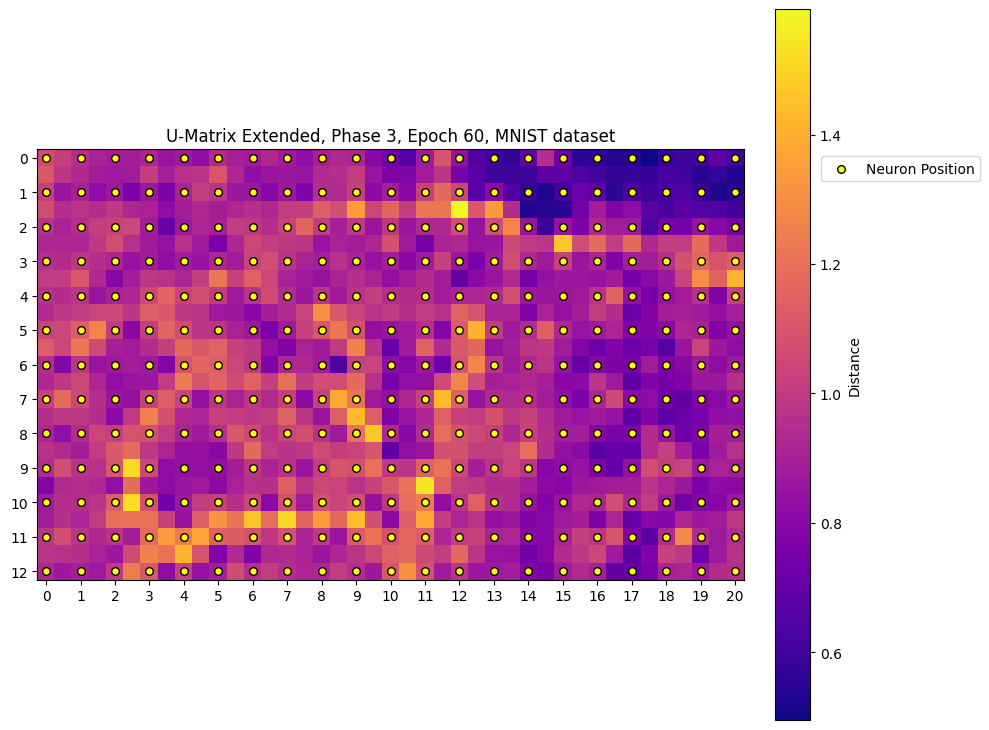

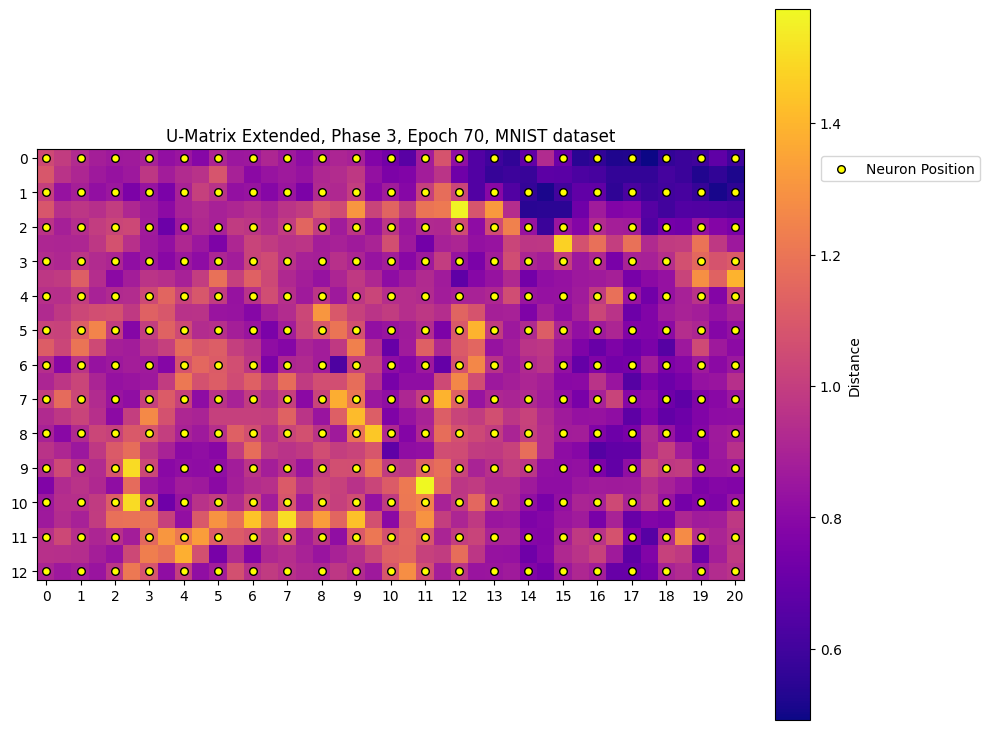

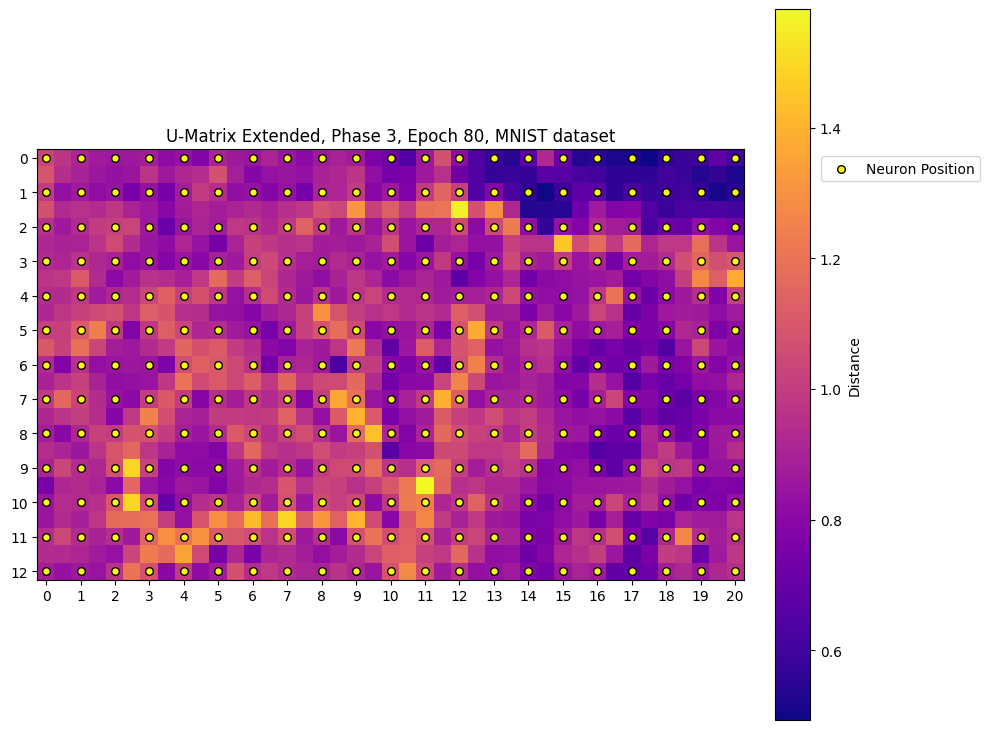

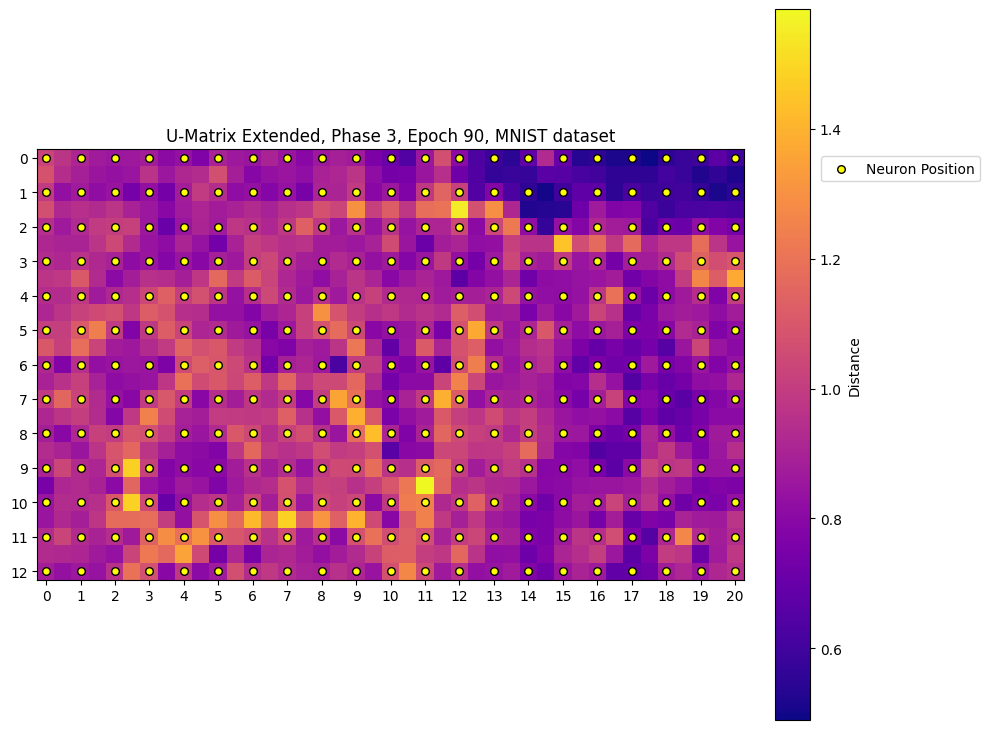

In [34]:
for i in range(0,100,10):
    rows, cols = autoencoder.get_som_shape()
    matrix = generate_extended_u_matrix(snapshot_som_weights_finetuning[i][0], rows, cols)
    visualize_u_matrix_extended(matrix, f"Phase 3, Epoch {i}, MNIST dataset")

Plot the change of the label matrix throughout the training process

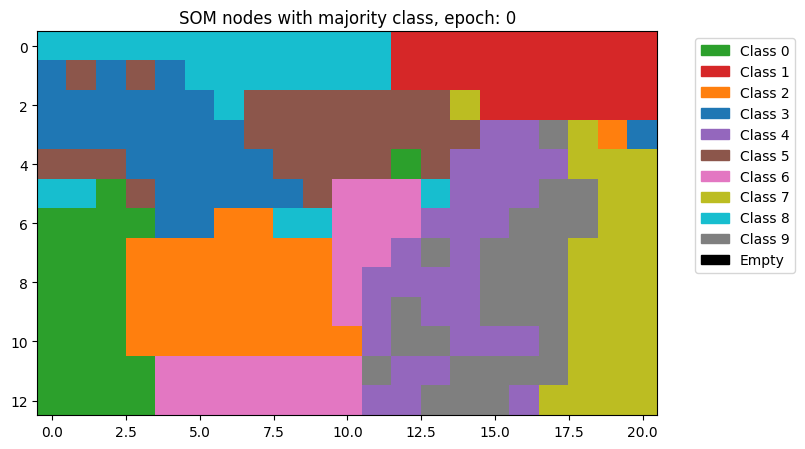

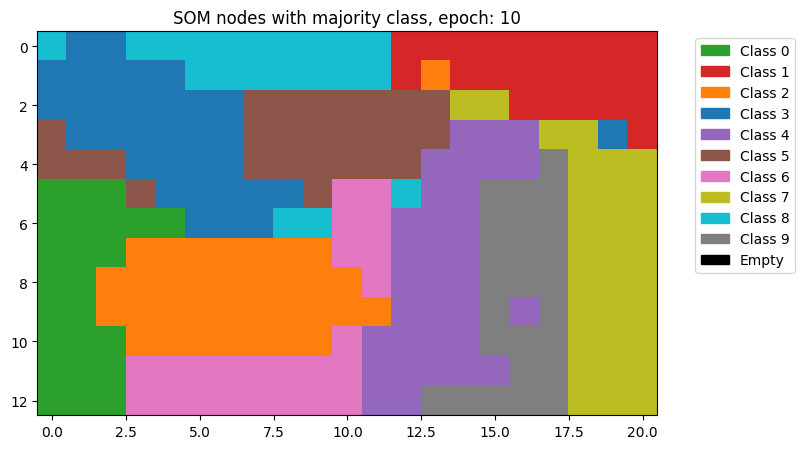

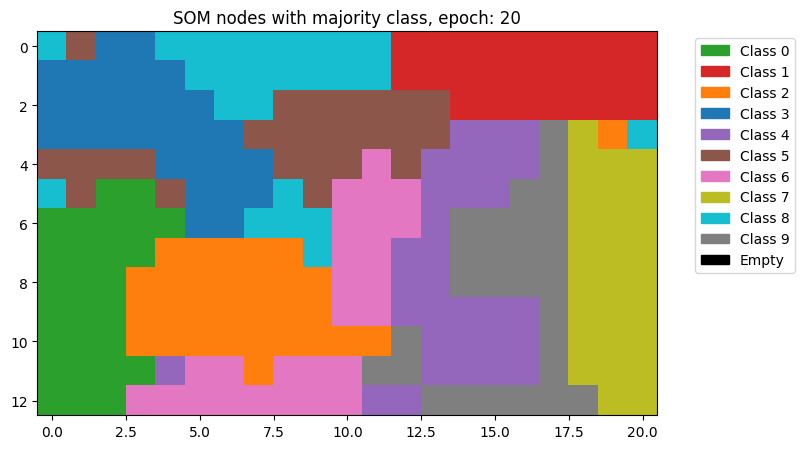

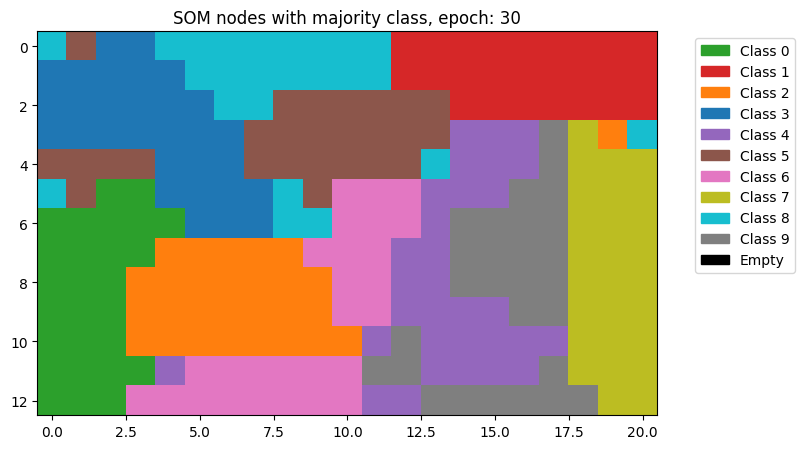

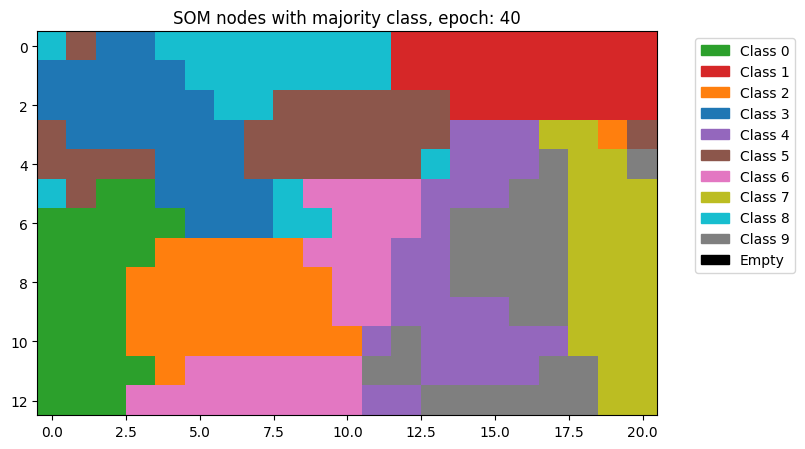

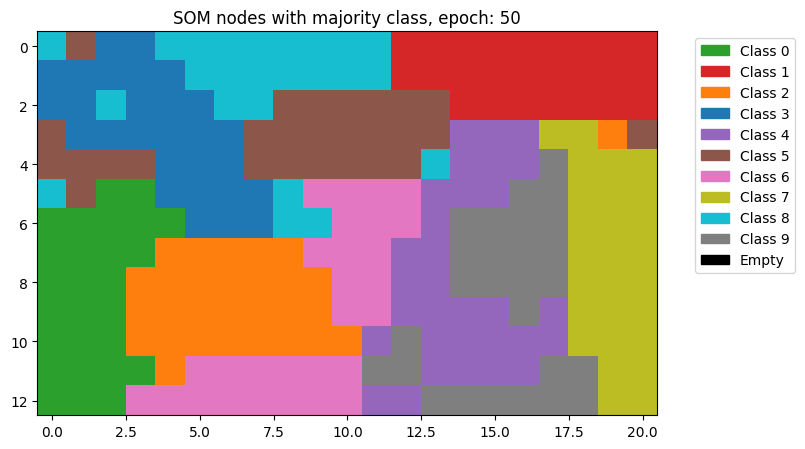

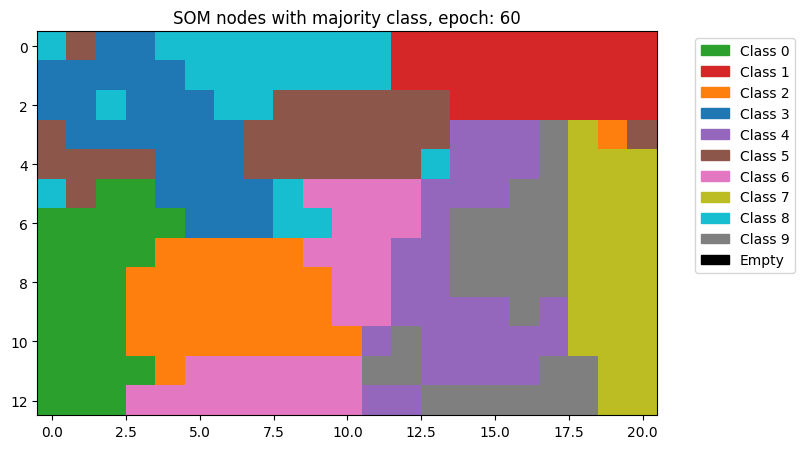

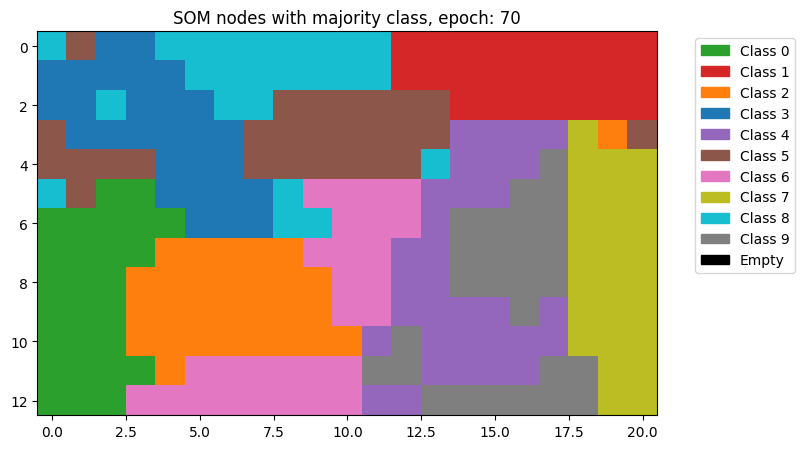

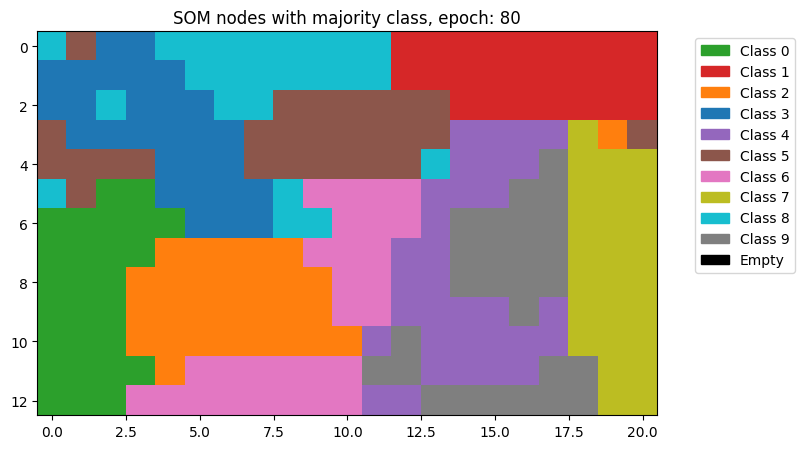

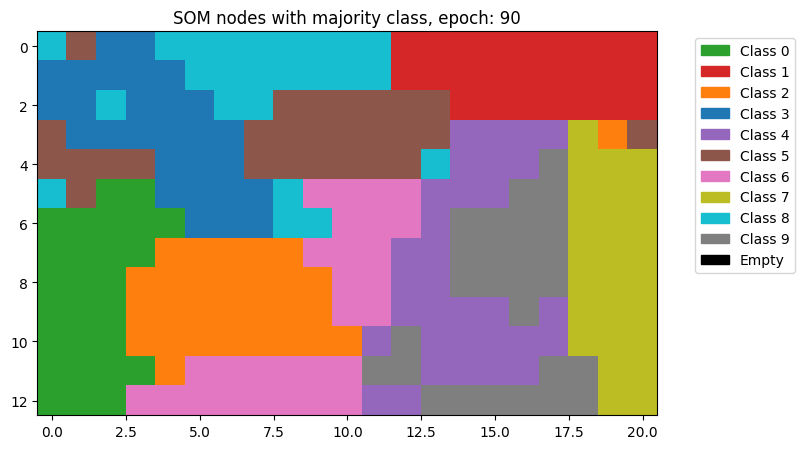

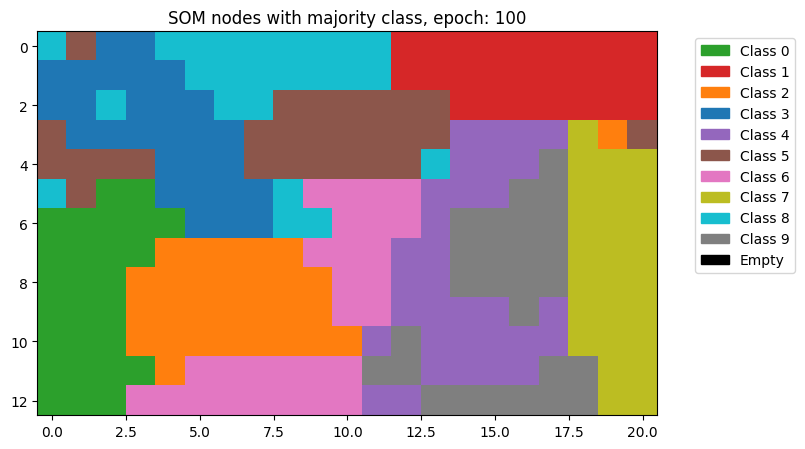

In [35]:
plot_som_weights(snapshot_som_weights_finetuning, final_rows, final_cols, unique_labels)

Plot the change of the UMAP throughout the Phase 3

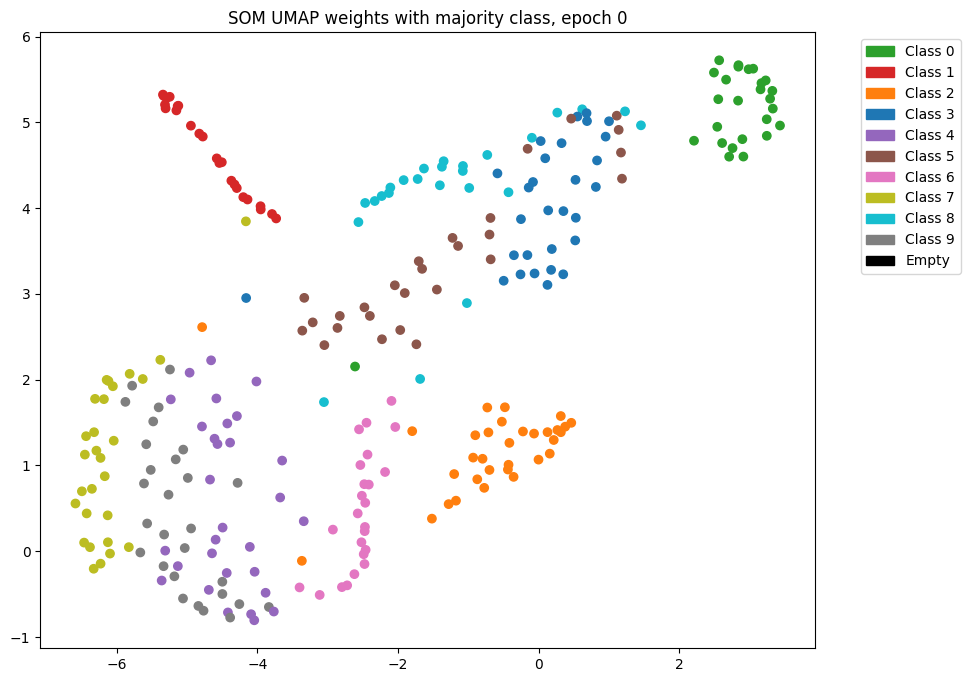

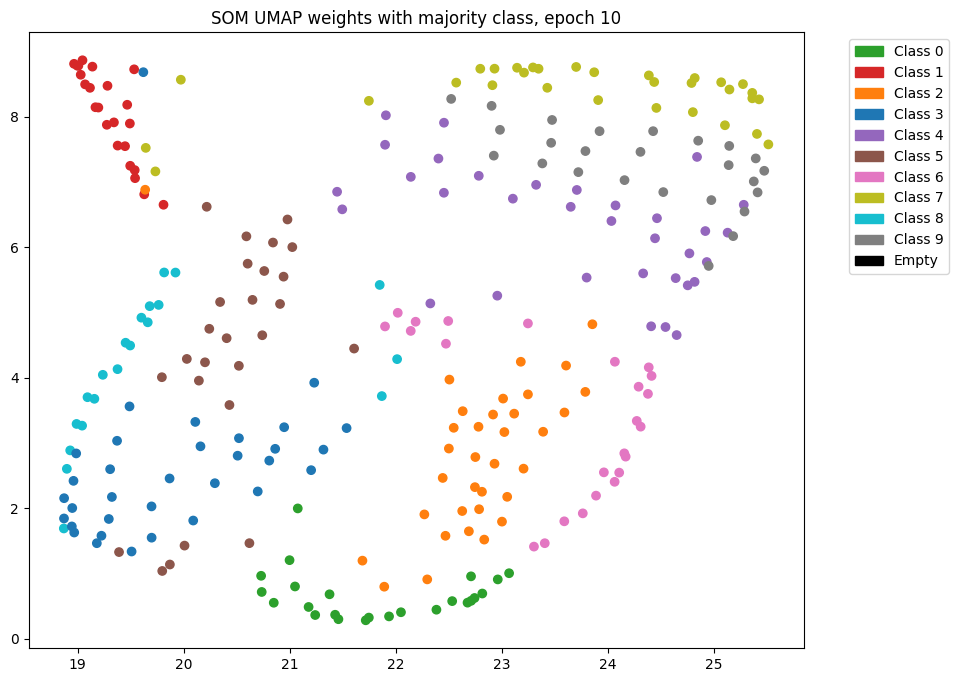

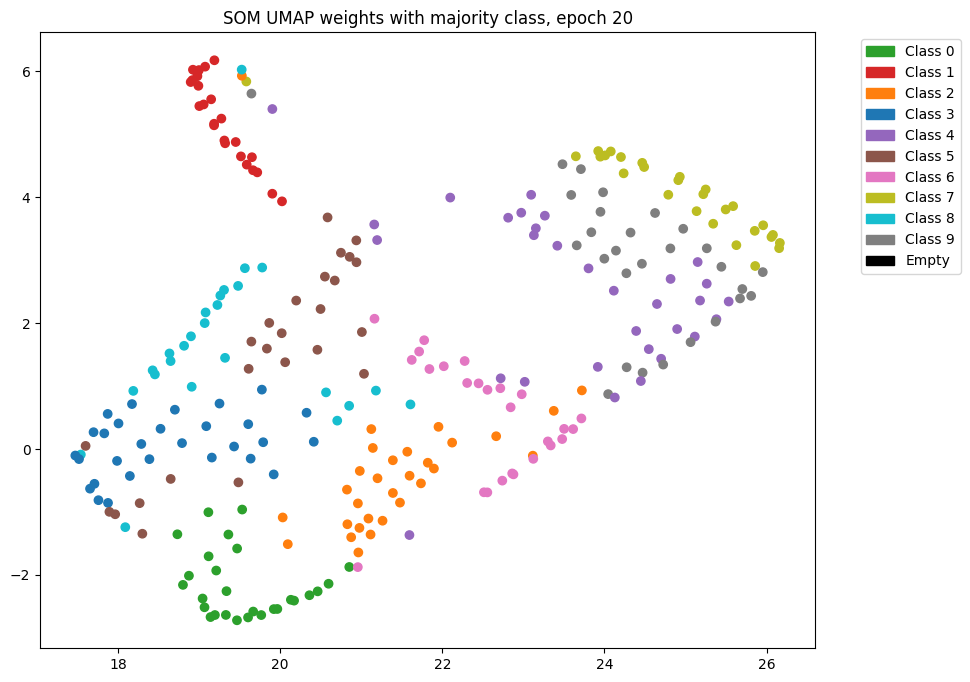

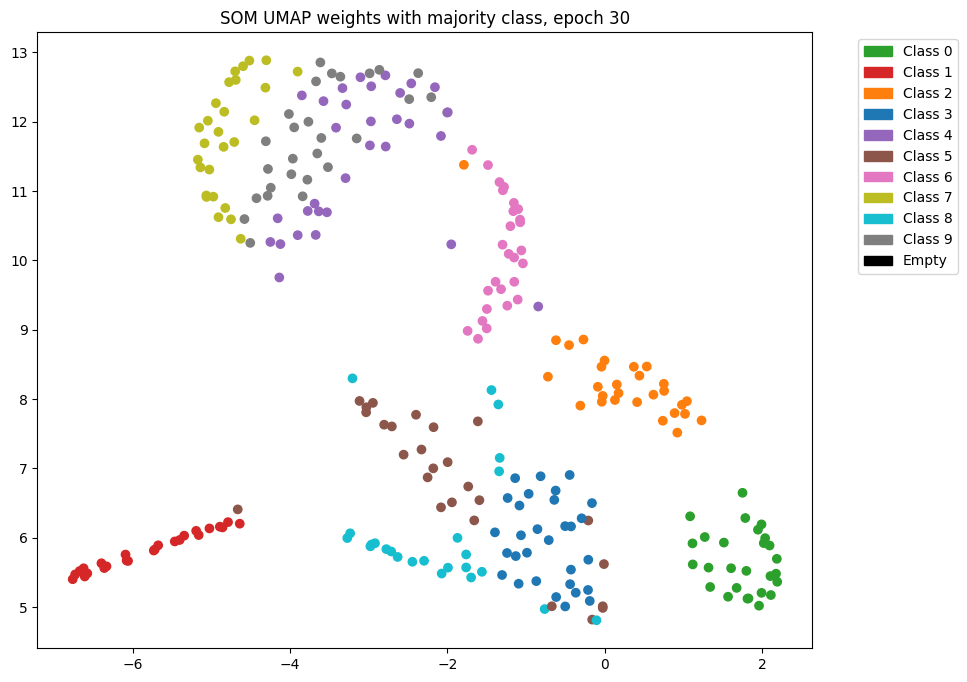

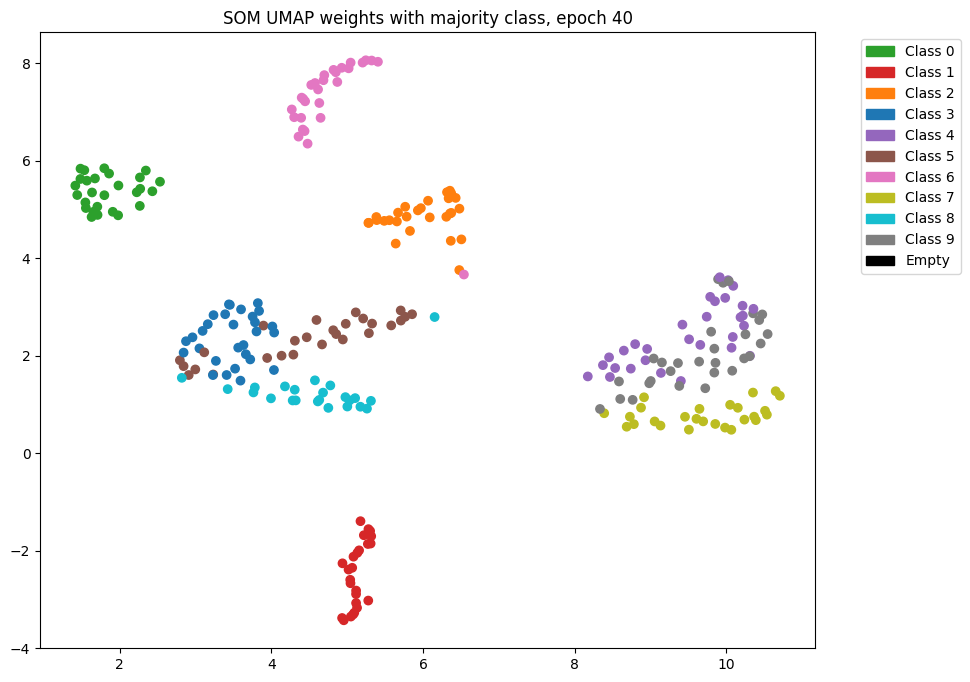

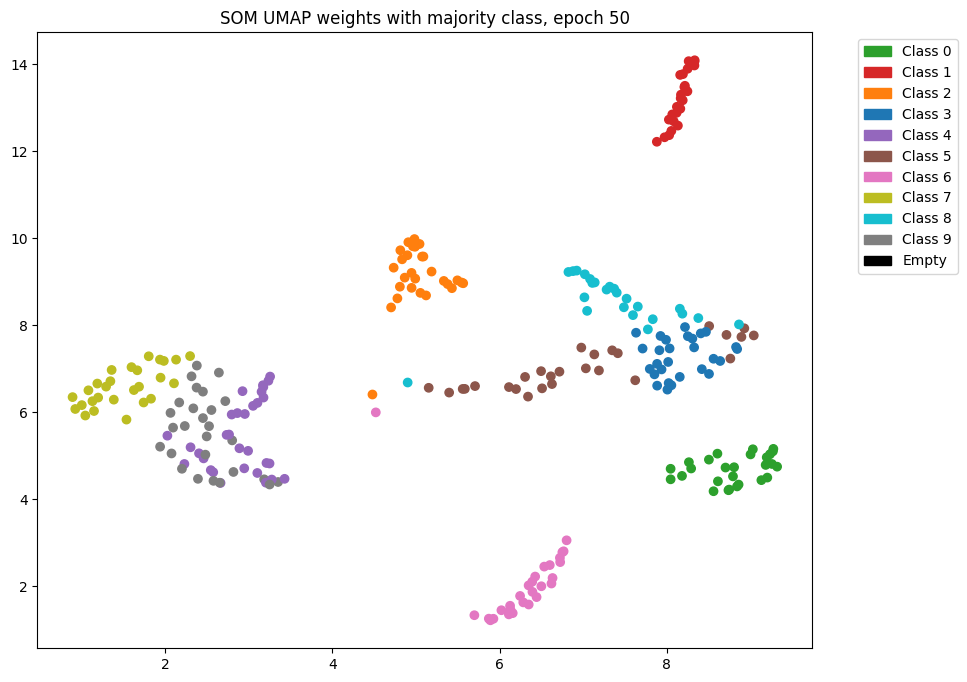

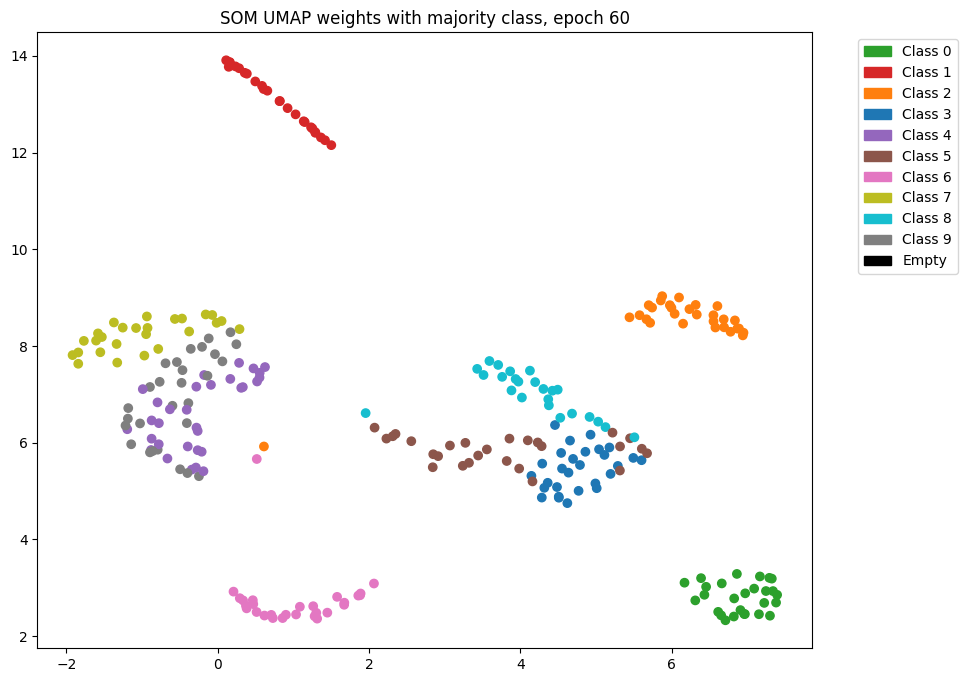

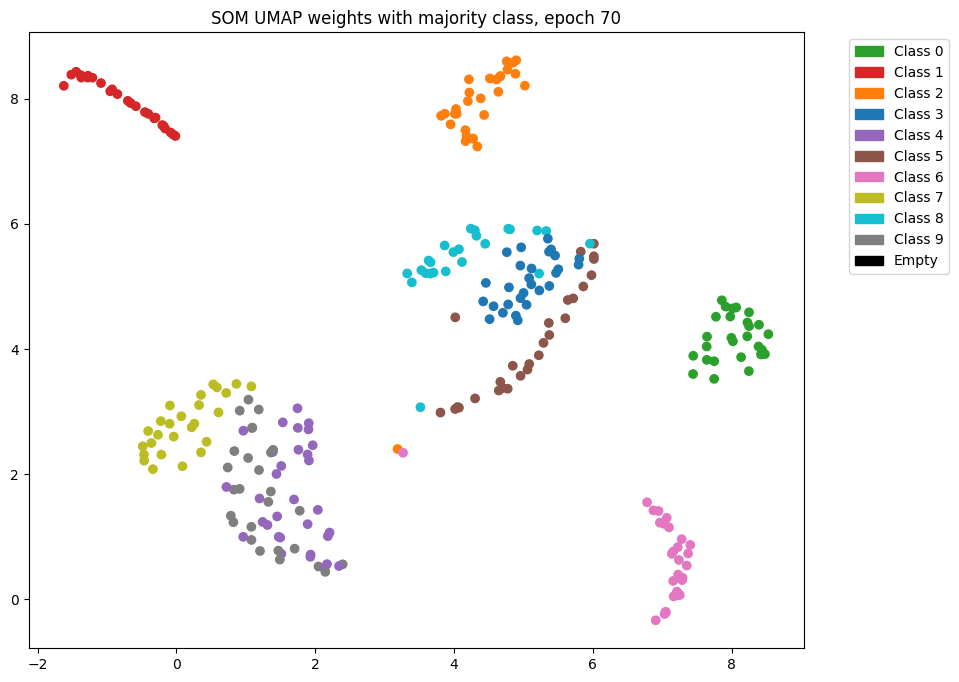

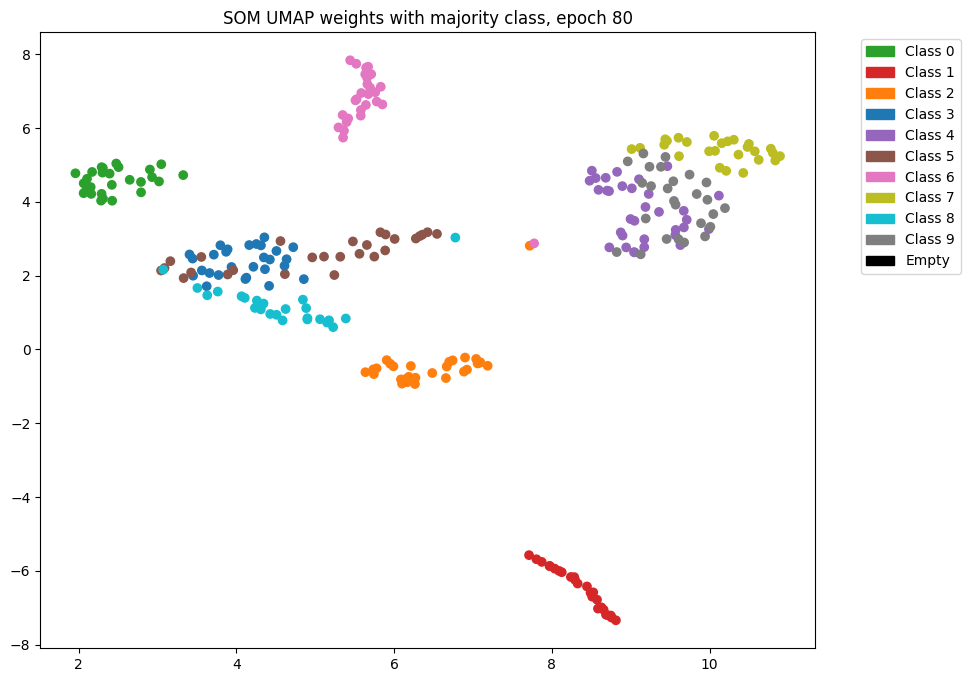

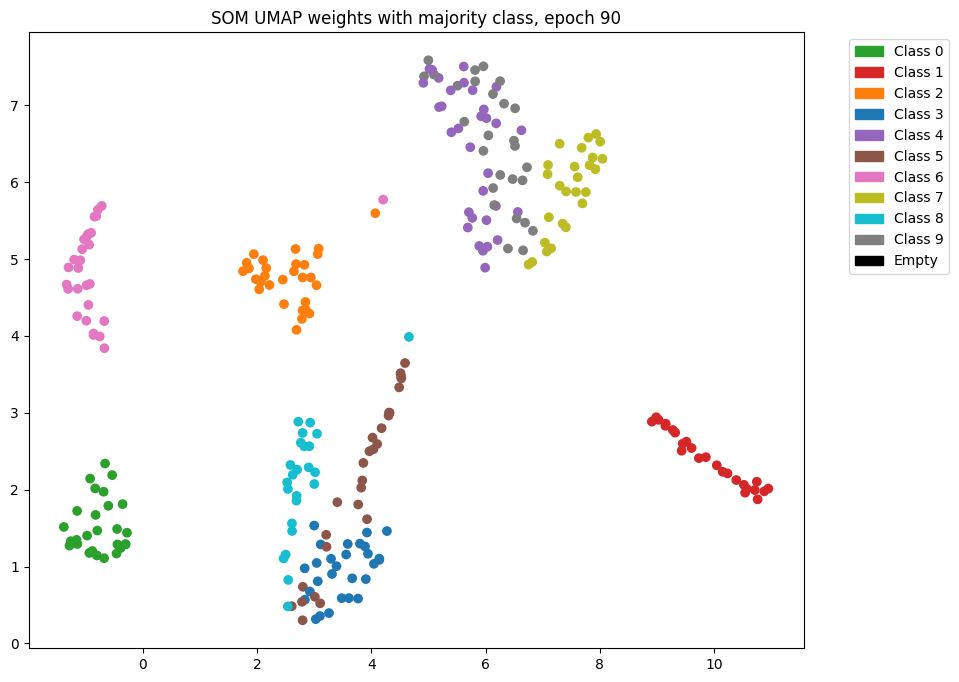

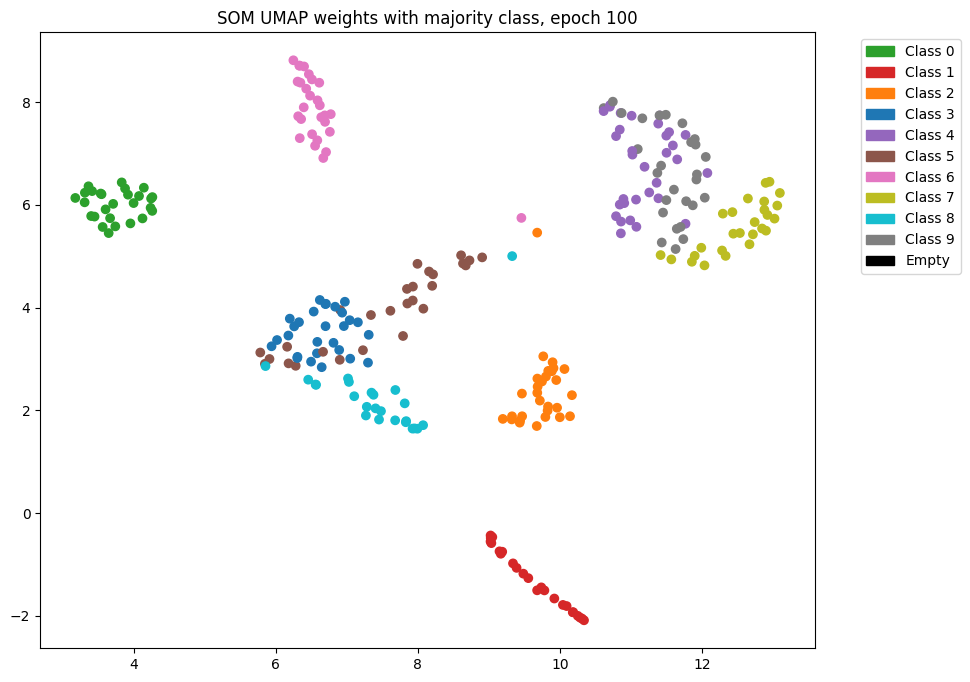

In [36]:
plot_umap_som_weights(snapshot_som_weights_finetuning, unique_labels)

Plot the majority label with the numbers representing the class

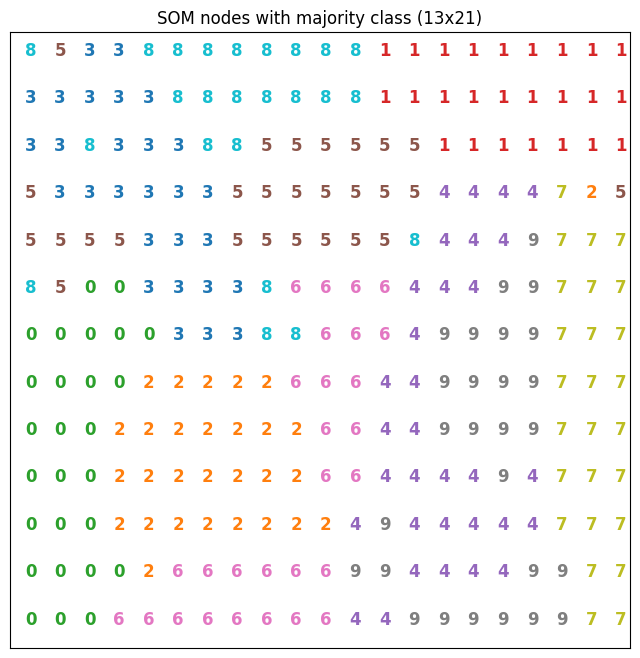

In [37]:
plot_som_mnist(snapshot_som_weights_finetuning, final_rows, final_cols)

Plot the pie charts with internal class distributions

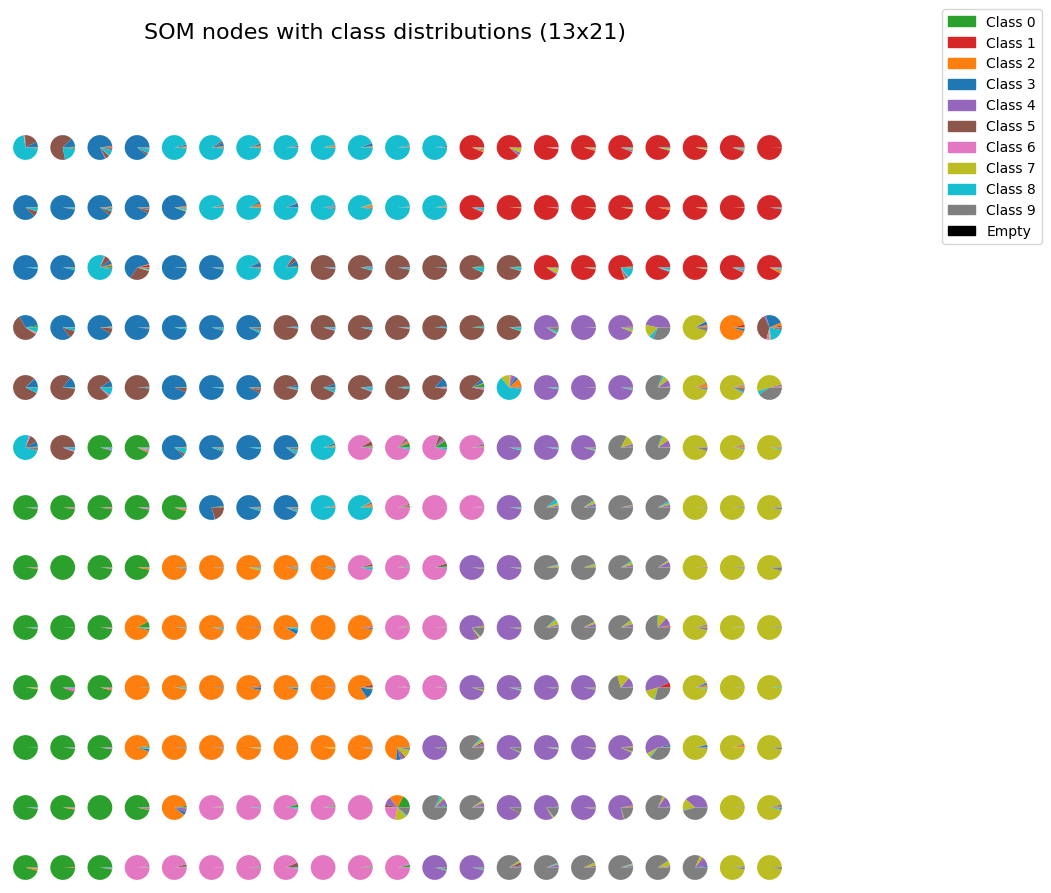

In [38]:
plot_som_pie_grid(snapshot_som_weights_finetuning, final_rows, final_cols, unique_labels)

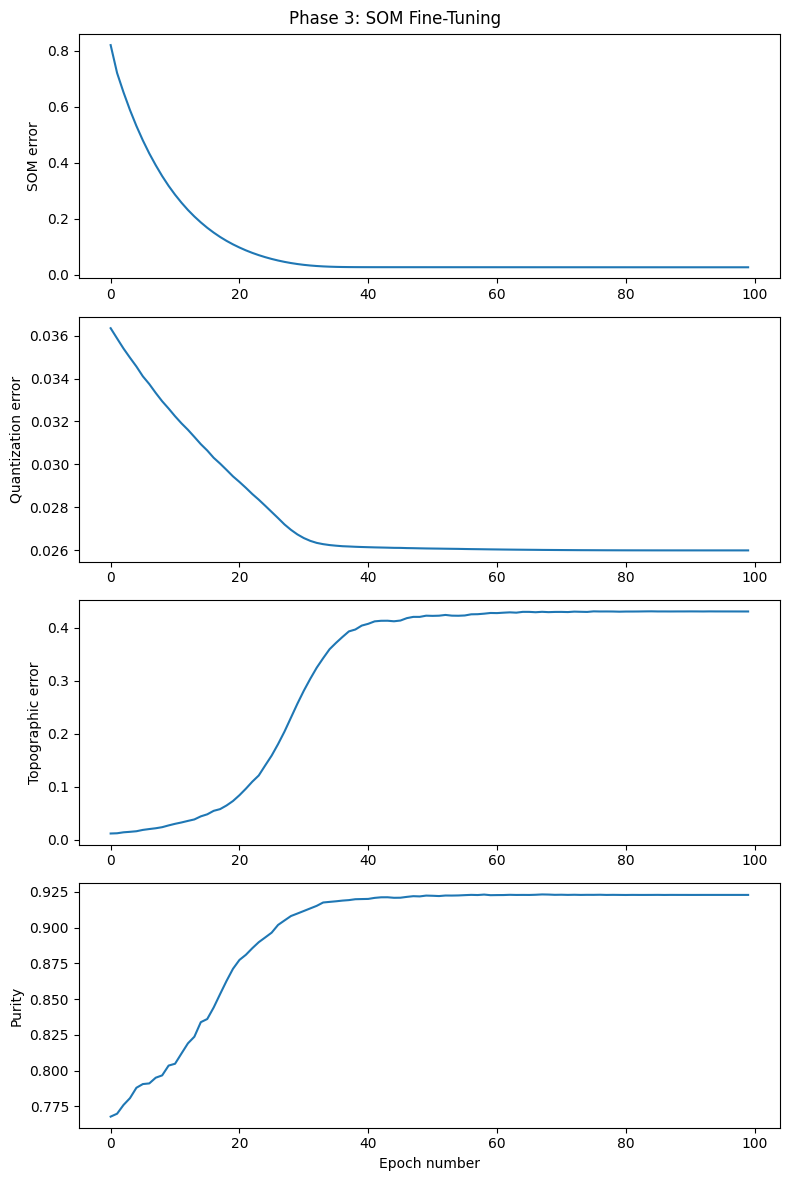

In [39]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)

plt.figure(figsize=(8, 12))

ax = plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.ylabel('SOM error')


ax = plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.ylabel('Quantization error')


ax = plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.ylabel('Topographic error')

ax = plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.suptitle("Phase 3: SOM Fine-Tuning")
plt.savefig("phase3.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()